In [1]:
# ============================================================
# AI AUTONOMOUS SOFTWARE RELIABILITY & OPTIMIZATION SYSTEM
# ============================================================
#
# Objective:
# Build an AI-powered system that continuously analyzes
# software runtime behaviour and detects potential problems
# before they become serious failures.
#
# Main Capabilities:
#
# 1. Failure Prediction
#    Predict potential service/application failures using
#    system metrics, logs, latency and execution patterns.
#
# 2. Memory-Leak Prediction & Localization
#    Detect abnormal memory growth and identify the
#    potentially affected service/component.
#
# 3. Dependency Intelligence
#    Analyze relationships between services and estimate
#    the possible impact of a service failure on dependencies.
#
# 4. Self-Optimization
#    Analyze workload and resource usage and generate
#    suitable runtime/resource optimization actions.
#
# Technologies:
# Python | Scikit-learn | XGBoost | Pandas | NumPy
# FastAPI | MCP | Docker | Streamlit
#
# Development Environment:
# Google Colab → AI/ML model development and training
# Docker       → Software/runtime environment
# FastAPI      → Backend API
# MCP          → AI/tool interaction
# Streamlit    → User Interface
#
# Final Goal:
# Create a complete AI-based software reliability platform
# capable of monitoring, predicting, analyzing and optimizing
# software runtime behaviour.
# ============================================================

print("AI Software Reliability & Optimization System")
print("Project initialization completed successfully.")


AI Software Reliability & Optimization System
Project initialization completed successfully.


In [2]:
# ============================================================
# CELL 2 — INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn
!pip install -q psutil networkx joblib

print("All required libraries installed successfully.")

All required libraries installed successfully.


In [3]:
# ============================================================
# CELL 3 — IMPORT LIBRARIES
# ============================================================

import os
import re
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    IsolationForest,
    RandomForestRegressor
)

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [7]:
# ============================================================
# CELL 4 — PROJECT CONFIGURATION
# ============================================================

BASE_PATH = "/content"

SYSTEM_METRICS_PATH = f"{BASE_PATH}/system_performance_metrics.csv"
PROCESSED_EVENTS_PATH = f"{BASE_PATH}/processed_events_analysis.csv"
ANOMALY_LABELS_PATH = f"{BASE_PATH}/anomaly_labels.txt"

OPENSTACK_ABNORMAL_PATH = f"{BASE_PATH}/openstack_abnormal.log"
OPENSTACK_NORMAL1_PATH = f"{BASE_PATH}/openstack_normal1.log"
OPENSTACK_NORMAL2_PATH = f"{BASE_PATH}/openstack_normal2.log"

BGL_PATH = f"{BASE_PATH}/BGL.log"
SORTED_LOG_PATH = f"{BASE_PATH}/sorted.log"

MODEL_DIR = f"{BASE_PATH}/models"
OUTPUT_DIR = f"{BASE_PATH}/outputs"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Project configuration completed successfully!")

print("\nAvailable datasets:")
for path in [
    SYSTEM_METRICS_PATH,
    PROCESSED_EVENTS_PATH,
    ANOMALY_LABELS_PATH,
    OPENSTACK_ABNORMAL_PATH,
    OPENSTACK_NORMAL1_PATH,
    OPENSTACK_NORMAL2_PATH,
    BGL_PATH,
    SORTED_LOG_PATH
]:
    print("✔", os.path.basename(path))

Project configuration completed successfully!

Available datasets:
✔ system_performance_metrics.csv
✔ processed_events_analysis.csv
✔ anomaly_labels.txt
✔ openstack_abnormal.log
✔ openstack_normal1.log
✔ openstack_normal2.log
✔ BGL.log
✔ sorted.log


In [8]:
system_metrics = pd.read_csv(SYSTEM_METRICS_PATH)

print("System Metrics Dataset Loaded Successfully!")
print("Shape:", system_metrics.shape)

display(system_metrics.head())

System Metrics Dataset Loaded Successfully!
Shape: (1440, 4)


,timestamp,cpu_usage,memory_usage,disk_usage
0,2025-07-21 00:00:00,42.483571,62.651525,43.285306
1,2025-07-21 00:01:00,39.570475,64.871898,43.725165
2,2025-07-21 00:02:00,43.762015,61.080079,48.353929
3,2025-07-21 00:03:00,48.400458,55.346628,51.634829
4,2025-07-21 00:04:00,39.876218,62.310631,42.106480


In [9]:
# ============================================================
# CELL 6 — LOAD PROCESSED EVENTS DATASET
# ============================================================

processed_events = pd.read_csv(PROCESSED_EVENTS_PATH)

print("Processed Events Dataset Loaded Successfully!")
print("Shape:", processed_events.shape)

display(processed_events.head())
print("\nColumns:")
print(processed_events.columns.tolist())

Processed Events Dataset Loaded Successfully!
Shape: (1746, 35)


,received_at,environment,project,event_count,schema_version,sdk_version,event_type,category,severity,status,...,method,path,status_code,duration_ms,hour,date,day_of_week,month,week,day
0,2026-02-20T13:00:53.883351,production,client-test-app,2,1.0,2.0.0,LOG,APPLICATION,HIGH,FAILURE,...,NaN,NaN,NaN,NaN,13,2026-02-20,Friday,2,8,20
1,2026-02-20T13:00:53.883351,production,client-test-app,2,1.0,2.0.0,INCOMING_REQUEST,APPLICATION,LOW,SUCCESS,...,GET,/log-error,200.0,0.0,13,2026-02-20,Friday,2,8,20
2,2026-02-20T13:04:48.940264,production,client-test-app,3,1.0,2.0.0,LOG,APPLICATION,HIGH,FAILURE,...,NaN,NaN,NaN,NaN,13,2026-02-20,Friday,2,8,20
3,2026-02-20T13:04:48.940264,production,client-test-app,3,1.0,2.0.0,SERVER_ERROR,APPLICATION,LOW,FAILURE,...,NaN,NaN,NaN,NaN,13,2026-02-20,Friday,2,8,20
4,2026-02-20T13:04:48.940264,production,client-test-app,3,1.0,2.0.0,SERVER_ERROR,APPLICATION,LOW,FAILURE,...,NaN,NaN,NaN,NaN,13,2026-02-20,Friday,2,8,20



Columns:
['received_at', 'environment', 'project', 'event_count', 'schema_version', 'sdk_version', 'event_type', 'category', 'severity', 'status', 'timestamp', 'hostname', 'os', 'os_version', 'python_version', 'region', 'app_version', 'instance_id', 'process_id', 'trace_id', 'message', 'file', 'line', 'logger_name', 'level', 'method', 'path', 'status_code', 'duration_ms', 'hour', 'date', 'day_of_week', 'month', 'week', 'day']


In [10]:
# ============================================================
# CELL 7 — LOAD ANOMALY LABELS
# ============================================================

with open(ANOMALY_LABELS_PATH, "r", encoding="utf-8") as f:
    anomaly_labels = f.readlines()

print("Anomaly Labels Loaded Successfully!")
print("Number of labels:", len(anomaly_labels))

print("\nSample labels:")
for label in anomaly_labels[:10]:
    print(label.strip())

Anomaly Labels Loaded Successfully!
Number of labels: 6

Sample labels:
The following VM instances have injected anomalies as observed in openstack_abnormal.log.

544fd51c-4edc-4780-baae-ba1d80a0acfc
ae651dff-c7ad-43d6-ac96-bbcd820ccca8
a445709b-6ad0-40ec-8860-bec60b6ca0c2
1643649d-2f42-4303-bfcd-7798baec19f9


In [12]:
# ============================================================
# CELL 8 — LOAD OPENSTACK LOGS
# ============================================================

openstack_abnormal = pd.DataFrame({
    "log": open(OPENSTACK_ABNORMAL_PATH, "r", encoding="utf-8", errors="ignore").readlines()
})

openstack_normal1 = pd.DataFrame({
    "log": open(OPENSTACK_NORMAL1_PATH, "r", encoding="utf-8", errors="ignore").readlines()
})

openstack_normal2 = pd.DataFrame({
    "log": open(OPENSTACK_NORMAL2_PATH, "r", encoding="utf-8", errors="ignore").readlines()
})

# Remove newline characters
for df in [openstack_abnormal, openstack_normal1, openstack_normal2]:
    df["log"] = df["log"].str.strip()

print("OpenStack Logs Loaded Successfully!")

print("\nAbnormal Log:", openstack_abnormal.shape)
print("Normal Log 1:", openstack_normal1.shape)
print("Normal Log 2:", openstack_normal2.shape)

print("\nSample abnormal logs:")
display(openstack_abnormal.head())

OpenStack Logs Loaded Successfully!

Abnormal Log: (18434, 1)
Normal Log 1: (52312, 1)
Normal Log 2: (137074, 1)

Sample abnormal logs:


,log
0,nova-api.log.2017-05-14_21:27:04 2017-05-14 19...
1,nova-api.log.2017-05-14_21:27:04 2017-05-14 19...
2,nova-compute.log.2017-05-14_21:27:09 2017-05-1...
3,nova-api.log.2017-05-14_21:27:04 2017-05-14 19...
4,nova-compute.log.2017-05-14_21:27:09 2017-05-1...


In [13]:
# ============================================================
# CELL 9 — LOAD BGL LOG + DATASET OVERVIEW
# ============================================================

bgl_logs = pd.DataFrame({
    "log": open(BGL_PATH, "r", encoding="utf-8", errors="ignore").readlines()
})

bgl_logs["log"] = bgl_logs["log"].str.strip()

print("BGL Log Loaded Successfully!")
print("BGL Shape:", bgl_logs.shape)

print("\n========== DATASET OVERVIEW ==========")

print("\n1. System Metrics:")
print(system_metrics.shape)

print("\n2. Processed Events:")
print(processed_events.shape)

print("\n3. OpenStack Abnormal:")
print(openstack_abnormal.shape)

print("\n4. OpenStack Normal 1:")
print(openstack_normal1.shape)

print("\n5. OpenStack Normal 2:")
print(openstack_normal2.shape)

print("\n6. BGL Logs:")
print(bgl_logs.shape)

print("\nSample BGL logs:")
display(bgl_logs.head())

BGL Log Loaded Successfully!
BGL Shape: (4747963, 1)

========== DATASET OVERVIEW ==========

1. System Metrics:
(1440, 4)

2. Processed Events:
(1746, 35)

3. OpenStack Abnormal:
(18434, 1)

4. OpenStack Normal 1:
(52312, 1)

5. OpenStack Normal 2:
(137074, 1)

6. BGL Logs:
(4747963, 1)

Sample BGL logs:


,log
0,- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 20...
1,- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 20...
2,- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 20...
3,- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 20...
4,- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 20...


In [14]:
# ============================================================
# CELL 10 — CLEAN SYSTEM METRICS
# ============================================================

system_metrics["timestamp"] = pd.to_datetime(
    system_metrics["timestamp"],
    errors="coerce"
)

# Convert metric columns to numeric
metric_columns = [
    "cpu_usage",
    "memory_usage",
    "disk_usage"
]

for col in metric_columns:
    system_metrics[col] = pd.to_numeric(
        system_metrics[col],
        errors="coerce"
    )

# Remove invalid timestamps
system_metrics = system_metrics.dropna(
    subset=["timestamp"]
).reset_index(drop=True)

# Sort by time
system_metrics = system_metrics.sort_values(
    "timestamp"
).reset_index(drop=True)

print("System Metrics Cleaning Completed!")

print("\nShape:", system_metrics.shape)

print("\nMissing Values:")
print(system_metrics.isnull().sum())

print("\nData Types:")
print(system_metrics.dtypes)

display(system_metrics.head())

System Metrics Cleaning Completed!

Shape: (1440, 4)

Missing Values:
timestamp       0
cpu_usage       0
memory_usage    0
disk_usage      0
dtype: int64

Data Types:
timestamp       datetime64[ns]
cpu_usage              float64
memory_usage           float64
disk_usage             float64
dtype: object


,timestamp,cpu_usage,memory_usage,disk_usage
0,2025-07-21 00:00:00,42.483571,62.651525,43.285306
1,2025-07-21 00:01:00,39.570475,64.871898,43.725165
2,2025-07-21 00:02:00,43.762015,61.080079,48.353929
3,2025-07-21 00:03:00,48.400458,55.346628,51.634829
4,2025-07-21 00:04:00,39.876218,62.310631,42.106480


In [15]:
# ============================================================
# CELL 11 — CLEAN PROCESSED EVENTS
# ============================================================

# Convert timestamp columns
processed_events["received_at"] = pd.to_datetime(
    processed_events["received_at"],
    errors="coerce"
)

processed_events["timestamp"] = pd.to_datetime(
    processed_events["timestamp"],
    errors="coerce"
)

# Convert numeric columns
numeric_columns = [
    "event_count",
    "schema_version",
    "status_code",
    "duration_ms",
    "hour",
    "month",
    "week",
    "day"
]

for col in numeric_columns:
    processed_events[col] = pd.to_numeric(
        processed_events[col],
        errors="coerce"
    )

# Remove rows without timestamps
processed_events = processed_events.dropna(
    subset=["received_at"]
).reset_index(drop=True)

# Sort chronologically
processed_events = processed_events.sort_values(
    "received_at"
).reset_index(drop=True)

print("Processed Events Cleaning Completed!")

print("\nShape:", processed_events.shape)

print("\nMissing Values:")
print(processed_events.isnull().sum().sort_values(ascending=False).head(10))

print("\nEvent Types:")
print(processed_events["event_type"].value_counts().head(10))

display(processed_events.head())

Processed Events Cleaning Completed!

Shape: (1746, 35)

Missing Values:
file           1677
line           1677
logger_name    1677
message        1677
level          1677
method         1202
status_code    1202
duration_ms    1202
path           1202
received_at       0
dtype: int64

Event Types:
event_type
DB_QUERY            717
INCOMING_REQUEST    544
SERVER_ERROR        194
ROUTING_ERROR       110
LOG                  69
HTTP_EXCEPTION       50
DB_ERROR             33
HTTP_ERROR           17
HTTP_CALL            12
Name: count, dtype: int64


,received_at,environment,project,event_count,schema_version,sdk_version,event_type,category,severity,status,...,method,path,status_code,duration_ms,hour,date,day_of_week,month,week,day
0,2026-02-20 13:00:53.883351,production,client-test-app,2,1.0,2.0.0,LOG,APPLICATION,HIGH,FAILURE,...,NaN,NaN,NaN,NaN,13,2026-02-20,Friday,2,8,20
1,2026-02-20 13:00:53.883351,production,client-test-app,2,1.0,2.0.0,INCOMING_REQUEST,APPLICATION,LOW,SUCCESS,...,GET,/log-error,200.0,0.0,13,2026-02-20,Friday,2,8,20
2,2026-02-20 13:04:48.940264,production,client-test-app,3,1.0,2.0.0,LOG,APPLICATION,HIGH,FAILURE,...,NaN,NaN,NaN,NaN,13,2026-02-20,Friday,2,8,20
3,2026-02-20 13:04:48.940264,production,client-test-app,3,1.0,2.0.0,SERVER_ERROR,APPLICATION,LOW,FAILURE,...,NaN,NaN,NaN,NaN,13,2026-02-20,Friday,2,8,20
4,2026-02-20 13:04:48.940264,production,client-test-app,3,1.0,2.0.0,SERVER_ERROR,APPLICATION,LOW,FAILURE,...,NaN,NaN,NaN,NaN,13,2026-02-20,Friday,2,8,20


In [16]:
# ============================================================
# CELL 12 — PARSE OPENSTACK LOGS
# ============================================================

# Combine abnormal + normal OpenStack logs
openstack_logs = pd.concat(
    [
        openstack_abnormal.assign(source="abnormal"),
        openstack_normal1.assign(source="normal"),
        openstack_normal2.assign(source="normal")
    ],
    ignore_index=True
)

# Extract timestamp
openstack_logs["timestamp"] = pd.to_datetime(
    openstack_logs["log"].str.extract(
        r"(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})"
    )[0],
    errors="coerce"
)

# Extract OpenStack service/file name
openstack_logs["service"] = openstack_logs["log"].str.extract(
    r"^([A-Za-z0-9_-]+\.log)"
)[0]

# Extract VM UUID
openstack_logs["vm_id"] = openstack_logs["log"].str.extract(
    r"([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12})",
    flags=re.IGNORECASE
)[0]

# Extract log level when present
openstack_logs["level"] = openstack_logs["log"].str.extract(
    r"\b(DEBUG|INFO|WARNING|WARN|ERROR|CRITICAL)\b",
    flags=re.IGNORECASE
)[0].str.upper()

# Remove rows without timestamps
openstack_logs = openstack_logs.dropna(
    subset=["timestamp"]
).reset_index(drop=True)

print("OpenStack Log Parsing Completed!")

print("\nShape:", openstack_logs.shape)

print("\nSources:")
print(openstack_logs["source"].value_counts())

print("\nServices:")
print(openstack_logs["service"].value_counts().head(10))

print("\nLog Levels:")
print(openstack_logs["level"].value_counts().head(10))

print("\nVM IDs detected:", openstack_logs["vm_id"].nunique())

display(
    openstack_logs[
        ["timestamp", "service", "vm_id", "level", "source", "log"]
    ].head()
)

OpenStack Log Parsing Completed!

Shape: (207820, 6)

Sources:
source
normal      189386
abnormal     18434
Name: count, dtype: int64

Services:
service
nova-compute.log      104086
nova-api.log          102868
nova-scheduler.log       866
Name: count, dtype: int64

Log Levels:
level
INFO        204506
WARNING       3118
ERROR          194
CRITICAL         2
Name: count, dtype: int64

VM IDs detected: 92475


,timestamp,service,vm_id,level,source,log
0,2017-05-14 19:39:01,nova-api.log,5a2050e7-b381-4ae9-92d2-8b08e9f9f4c0,INFO,abnormal,nova-api.log.2017-05-14_21:27:04 2017-05-14 19...
1,2017-05-14 19:39:01,nova-api.log,c26a7d54-55ab-412e-947f-421a2cb934fc,INFO,abnormal,nova-api.log.2017-05-14_21:27:04 2017-05-14 19...
2,2017-05-14 19:39:02,nova-compute.log,e285b551-587f-4c1d-8eba-dceb2673637f,INFO,abnormal,nova-compute.log.2017-05-14_21:27:09 2017-05-1...
3,2017-05-14 19:39:02,nova-api.log,eb681812-78ae-4a9f-9e2a-96e505285512,INFO,abnormal,nova-api.log.2017-05-14_21:27:04 2017-05-14 19...
4,2017-05-14 19:39:03,nova-compute.log,2b590f10-49fd-4ec9-ae41-19596c2f4b25,INFO,abnormal,nova-compute.log.2017-05-14_21:27:09 2017-05-1...


In [17]:
# ============================================================
# CELL 13 — HANDLE MISSING VALUES
# ============================================================

# Processed Events
processed_events["message"] = processed_events["message"].fillna("")
processed_events["file"] = processed_events["file"].fillna("")
processed_events["logger_name"] = processed_events["logger_name"].fillna("")
processed_events["level"] = processed_events["level"].fillna("UNKNOWN")
processed_events["method"] = processed_events["method"].fillna("UNKNOWN")
processed_events["path"] = processed_events["path"].fillna("UNKNOWN")

# Numeric fields
processed_events["status_code"] = processed_events["status_code"].fillna(0)
processed_events["duration_ms"] = processed_events["duration_ms"].fillna(0)

# OpenStack Logs
openstack_logs["service"] = openstack_logs["service"].fillna("UNKNOWN")
openstack_logs["level"] = openstack_logs["level"].fillna("UNKNOWN")
openstack_logs["vm_id"] = openstack_logs["vm_id"].fillna("UNKNOWN")

print("Missing Value Handling Completed!")

print("\nProcessed Events — Remaining Missing Values:")
print(processed_events.isnull().sum().sum())

print("\nOpenStack Logs — Remaining Missing Values:")
print(openstack_logs.isnull().sum().sum())

print("\nProcessed Events Shape:", processed_events.shape)
print("OpenStack Logs Shape:", openstack_logs.shape)

Missing Value Handling Completed!

Processed Events — Remaining Missing Values:
1677

OpenStack Logs — Remaining Missing Values:
0

Processed Events Shape: (1746, 35)
OpenStack Logs Shape: (207820, 6)


In [18]:
# ============================================================
# CELL 14 — ALIGN SYSTEM METRICS + APPLICATION EVENTS
# ============================================================

# Create minute-level timestamps
system_metrics["minute"] = system_metrics["timestamp"].dt.floor("min")

processed_events["minute"] = processed_events["received_at"].dt.floor("min")

# Aggregate application events per minute
event_features = processed_events.groupby("minute").agg(
    total_events=("event_type", "count"),
    failure_events=("status", lambda x: (x == "FAILURE").sum()),
    server_errors=("event_type", lambda x: (x == "SERVER_ERROR").sum()),
    routing_errors=("event_type", lambda x: (x == "ROUTING_ERROR").sum()),
    db_errors=("event_type", lambda x: (x == "DB_ERROR").sum()),
    http_errors=("event_type", lambda x: (x == "HTTP_ERROR").sum()),
    avg_duration_ms=("duration_ms", "mean"),
    max_duration_ms=("duration_ms", "max")
).reset_index()

# Merge with system metrics
runtime_data = pd.merge(
    system_metrics,
    event_features,
    on="minute",
    how="left"
)

# Fill minutes where no application event occurred
event_columns = [
    "total_events",
    "failure_events",
    "server_errors",
    "routing_errors",
    "db_errors",
    "http_errors",
    "avg_duration_ms",
    "max_duration_ms"
]

runtime_data[event_columns] = runtime_data[event_columns].fillna(0)

print("Timestamp Alignment Completed!")

print("\nRuntime Dataset Shape:", runtime_data.shape)

print("\nColumns:")
print(runtime_data.columns.tolist())

print("\nMissing Values:")
print(runtime_data.isnull().sum())

display(runtime_data.head())

Timestamp Alignment Completed!

Runtime Dataset Shape: (1440, 13)

Columns:
['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage', 'minute', 'total_events', 'failure_events', 'server_errors', 'routing_errors', 'db_errors', 'http_errors', 'avg_duration_ms', 'max_duration_ms']

Missing Values:
timestamp          0
cpu_usage          0
memory_usage       0
disk_usage         0
minute             0
total_events       0
failure_events     0
server_errors      0
routing_errors     0
db_errors          0
http_errors        0
avg_duration_ms    0
max_duration_ms    0
dtype: int64


,timestamp,cpu_usage,memory_usage,disk_usage,minute,total_events,failure_events,server_errors,routing_errors,db_errors,http_errors,avg_duration_ms,max_duration_ms
0,2025-07-21 00:00:00,42.483571,62.651525,43.285306,2025-07-21 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-07-21 00:01:00,39.570475,64.871898,43.725165,2025-07-21 00:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-07-21 00:02:00,43.762015,61.080079,48.353929,2025-07-21 00:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-07-21 00:03:00,48.400458,55.346628,51.634829,2025-07-21 00:03:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-07-21 00:04:00,39.876218,62.310631,42.106480,2025-07-21 00:04:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# ============================================================
# CELL 15 — CHECK TIMESTAMP RANGES
# ============================================================

print("SYSTEM METRICS")
print("Start:", system_metrics["timestamp"].min())
print("End  :", system_metrics["timestamp"].max())

print("\nPROCESSED EVENTS")
print("Start:", processed_events["received_at"].min())
print("End  :", processed_events["received_at"].max())

print("\nOPENSTACK LOGS")
print("Start:", openstack_logs["timestamp"].min())
print("End  :", openstack_logs["timestamp"].max())

print("\nRUNTIME DATA")
print("Start:", runtime_data["timestamp"].min())
print("End  :", runtime_data["timestamp"].max())

SYSTEM METRICS
Start: 2025-07-21 00:00:00
End  : 2025-07-21 23:59:00

PROCESSED EVENTS
Start: 2026-02-20 13:00:53.883351
End  : 2026-02-21 06:02:27.374946

OPENSTACK LOGS
Start: 2017-05-14 19:39:01
End  : 2017-05-17 12:02:35

RUNTIME DATA
Start: 2025-07-21 00:00:00
End  : 2025-07-21 23:59:00


In [20]:
# ============================================================
# CELL 16 — SYSTEM METRIC FEATURE ENGINEERING
# ============================================================

# Rolling statistics
runtime_data["cpu_mean_5"] = (
    runtime_data["cpu_usage"]
    .rolling(5, min_periods=1)
    .mean()
)

runtime_data["cpu_std_5"] = (
    runtime_data["cpu_usage"]
    .rolling(5, min_periods=1)
    .std()
    .fillna(0)
)

runtime_data["memory_mean_5"] = (
    runtime_data["memory_usage"]
    .rolling(5, min_periods=1)
    .mean()
)

runtime_data["memory_std_5"] = (
    runtime_data["memory_usage"]
    .rolling(5, min_periods=1)
    .std()
    .fillna(0)
)

runtime_data["disk_mean_5"] = (
    runtime_data["disk_usage"]
    .rolling(5, min_periods=1)
    .mean()
)

# Rate of change
runtime_data["cpu_change"] = runtime_data["cpu_usage"].diff().fillna(0)
runtime_data["memory_change"] = runtime_data["memory_usage"].diff().fillna(0)
runtime_data["disk_change"] = runtime_data["disk_usage"].diff().fillna(0)

# Resource pressure indicators
runtime_data["high_cpu"] = (
    runtime_data["cpu_usage"] > 80
).astype(int)

runtime_data["high_memory"] = (
    runtime_data["memory_usage"] > 80
).astype(int)

runtime_data["high_disk"] = (
    runtime_data["disk_usage"] > 80
).astype(int)

print("System Metric Feature Engineering Completed!")

print("\nNew Shape:", runtime_data.shape)

display(runtime_data.head())

System Metric Feature Engineering Completed!

New Shape: (1440, 24)


,timestamp,cpu_usage,memory_usage,disk_usage,minute,total_events,failure_events,server_errors,routing_errors,db_errors,...,cpu_std_5,memory_mean_5,memory_std_5,disk_mean_5,cpu_change,memory_change,disk_change,high_cpu,high_memory,high_disk
0,2025-07-21 00:00:00,42.483571,62.651525,43.285306,2025-07-21 00:00:00,0.0,0.0,0.0,0.0,0.0,...,0.000000,62.651525,0.000000,43.285306,0.000000,0.000000,0.000000,0,0,0
1,2025-07-21 00:01:00,39.570475,64.871898,43.725165,2025-07-21 00:01:00,0.0,0.0,0.0,0.0,0.0,...,2.059870,63.761712,1.570041,43.505236,-2.913096,2.220373,0.439859,0,0,0
2,2025-07-21 00:02:00,43.762015,61.080079,48.353929,2025-07-21 00:02:00,0.0,0.0,0.0,0.0,0.0,...,2.148238,62.867834,1.905142,45.121467,4.191540,-3.791820,4.628764,0,0,0
3,2025-07-21 00:03:00,48.400458,55.346628,51.634829,2025-07-21 00:03:00,0.0,0.0,0.0,0.0,0.0,...,3.676308,60.987533,4.069625,46.749807,4.638443,-5.733451,3.280901,0,0,0
4,2025-07-21 00:04:00,39.876218,62.310631,42.106480,2025-07-21 00:04:00,0.0,0.0,0.0,0.0,0.0,...,3.583551,61.252152,3.573724,45.821142,-8.524240,6.964003,-9.528349,0,0,0


In [21]:
# ============================================================
# CELL 17 — APPLICATION EVENT FEATURE ENGINEERING
# ============================================================

# Event-type indicators
processed_events["is_failure"] = (
    processed_events["status"] == "FAILURE"
).astype(int)

processed_events["is_error"] = (
    processed_events["event_type"].str.contains(
        "ERROR|EXCEPTION",
        case=False,
        na=False
    )
).astype(int)

processed_events["is_server_error"] = (
    processed_events["event_type"] == "SERVER_ERROR"
).astype(int)

processed_events["is_db_error"] = (
    processed_events["event_type"] == "DB_ERROR"
).astype(int)

processed_events["is_routing_error"] = (
    processed_events["event_type"] == "ROUTING_ERROR"
).astype(int)

# Aggregate by minute
application_features = processed_events.groupby("minute").agg(
    total_events=("event_type", "count"),
    failures=("is_failure", "sum"),
    errors=("is_error", "sum"),
    server_errors=("is_server_error", "sum"),
    db_errors=("is_db_error", "sum"),
    routing_errors=("is_routing_error", "sum"),
    avg_latency=("duration_ms", "mean"),
    max_latency=("duration_ms", "max")
).reset_index()

# Replace invalid latency values
application_features[
    ["avg_latency", "max_latency"]
] = application_features[
    ["avg_latency", "max_latency"]
].fillna(0)

print("Application Event Feature Engineering Completed!")

print("\nShape:", application_features.shape)

print("\nColumns:")
print(application_features.columns.tolist())

display(application_features.head())

Application Event Feature Engineering Completed!

Shape: (39, 9)

Columns:
['minute', 'total_events', 'failures', 'errors', 'server_errors', 'db_errors', 'routing_errors', 'avg_latency', 'max_latency']


,minute,total_events,failures,errors,server_errors,db_errors,routing_errors,avg_latency,max_latency
0,2026-02-20 13:00:00,2,1,0,0,0,0,0.000000,0.0
1,2026-02-20 13:04:00,3,3,2,2,0,0,0.000000,0.0
2,2026-02-20 13:36:00,45,9,9,1,0,4,104.644444,3786.0
3,2026-02-20 13:37:00,50,11,10,4,1,2,119.040000,4004.0
4,2026-02-20 13:38:00,62,20,17,6,3,7,98.241935,3431.0


In [22]:
# ============================================================
# CELL 18 — OPENSTACK FEATURE ENGINEERING
# ============================================================

# Create error indicators
openstack_logs["is_error"] = openstack_logs["level"].isin(
    ["ERROR", "CRITICAL"]
).astype(int)

openstack_logs["is_warning"] = (
    openstack_logs["level"] == "WARNING"
).astype(int)

openstack_logs["is_abnormal"] = (
    openstack_logs["source"] == "abnormal"
).astype(int)

# Service-level aggregation
openstack_features = openstack_logs.groupby(
    "service"
).agg(
    total_logs=("log", "count"),
    error_count=("is_error", "sum"),
    warning_count=("is_warning", "sum"),
    abnormal_logs=("is_abnormal", "sum"),
    unique_vms=("vm_id", "nunique")
).reset_index()

# Error rate
openstack_features["error_rate"] = (
    openstack_features["error_count"] /
    openstack_features["total_logs"]
)

# Abnormal rate
openstack_features["abnormal_rate"] = (
    openstack_features["abnormal_logs"] /
    openstack_features["total_logs"]
)

print("OpenStack Feature Engineering Completed!")

print("\nShape:", openstack_features.shape)

display(openstack_features)

OpenStack Feature Engineering Completed!

Shape: (3, 8)


,service,total_logs,error_count,warning_count,abnormal_logs,unique_vms,error_rate,abnormal_rate
0,nova-api.log,102868,4,2,9808,89536,0.000039,0.095345
1,nova-compute.log,104086,192,3116,8559,6204,0.001845,0.082230
2,nova-scheduler.log,866,0,0,67,866,0.000000,0.077367


In [23]:
# ============================================================
# CELL 19 — BGL FEATURE EXTRACTION
# ============================================================

# Work directly on the log text
bgl_text = bgl_logs["log"]

# Detect error/warning/failure indicators
bgl_error_count = bgl_text.str.contains(
    r"\b(ERROR|FATAL|FAILURE|CRITICAL)\b",
    case=False,
    regex=True,
    na=False
).sum()

bgl_warning_count = bgl_text.str.contains(
    r"\b(WARNING|WARN)\b",
    case=False,
    regex=True,
    na=False
).sum()

bgl_fatal_count = bgl_text.str.contains(
    r"\b(FATAL|CRITICAL)\b",
    case=False,
    regex=True,
    na=False
).sum()

# Total logs
bgl_total_logs = len(bgl_logs)

# Create compact feature table
bgl_features = pd.DataFrame({
    "total_logs": [bgl_total_logs],
    "error_count": [bgl_error_count],
    "warning_count": [bgl_warning_count],
    "fatal_count": [bgl_fatal_count]
})

bgl_features["error_rate"] = (
    bgl_features["error_count"] /
    bgl_features["total_logs"]
)

bgl_features["warning_rate"] = (
    bgl_features["warning_count"] /
    bgl_features["total_logs"]
)

print("BGL Feature Extraction Completed!")

display(bgl_features)

BGL Feature Extraction Completed!


,total_logs,error_count,warning_count,fatal_count,error_rate,warning_rate
0,4747963,1310931,34585,1001828,0.276104,0.007284


In [24]:
# ============================================================
# CELL 20 — TIME-SERIES FEATURE ENGINEERING
# ============================================================

# Short-term rolling statistics
runtime_data["cpu_mean_10"] = (
    runtime_data["cpu_usage"]
    .rolling(10, min_periods=1)
    .mean()
)

runtime_data["memory_mean_10"] = (
    runtime_data["memory_usage"]
    .rolling(10, min_periods=1)
    .mean()
)

runtime_data["disk_mean_10"] = (
    runtime_data["disk_usage"]
    .rolling(10, min_periods=1)
    .mean()
)

# Longer-term rolling statistics
runtime_data["cpu_mean_30"] = (
    runtime_data["cpu_usage"]
    .rolling(30, min_periods=1)
    .mean()
)

runtime_data["memory_mean_30"] = (
    runtime_data["memory_usage"]
    .rolling(30, min_periods=1)
    .mean()
)

runtime_data["disk_mean_30"] = (
    runtime_data["disk_usage"]
    .rolling(30, min_periods=1)
    .mean()
)

# Trend relative to longer window
runtime_data["cpu_trend"] = (
    runtime_data["cpu_mean_10"] -
    runtime_data["cpu_mean_30"]
)

runtime_data["memory_trend"] = (
    runtime_data["memory_mean_10"] -
    runtime_data["memory_mean_30"]
)

runtime_data["disk_trend"] = (
    runtime_data["disk_mean_10"] -
    runtime_data["disk_mean_30"]
)

print("Time-Series Feature Engineering Completed!")

print("\nShape:", runtime_data.shape)

display(
    runtime_data[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "cpu_trend",
            "memory_trend",
            "disk_trend"
        ]
    ].head(10)
)

Time-Series Feature Engineering Completed!

Shape: (1440, 33)


,timestamp,cpu_usage,memory_usage,disk_usage,cpu_trend,memory_trend,disk_trend
0,2025-07-21 00:00:00,42.483571,62.651525,43.285306,0.0,0.0,0.0
1,2025-07-21 00:01:00,39.570475,64.871898,43.725165,0.0,0.0,0.0
2,2025-07-21 00:02:00,43.762015,61.080079,48.353929,0.0,0.0,0.0
3,2025-07-21 00:03:00,48.400458,55.346628,51.634829,0.0,0.0,0.0
4,2025-07-21 00:04:00,39.876218,62.310631,42.106480,0.0,0.0,0.0
5,2025-07-21 00:05:00,40.137897,58.284321,48.937003,0.0,0.0,0.0
6,2025-07-21 00:06:00,49.466143,58.953086,48.944616,0.0,0.0,0.0
7,2025-07-21 00:07:00,45.668630,63.590732,54.775499,0.0,0.0,0.0
8,2025-07-21 00:08:00,39.745322,66.376040,49.542499,0.0,0.0,0.0
9,2025-07-21 00:09:00,45.066573,61.685518,51.933558,0.0,0.0,0.0


In [25]:
# ============================================================
# CELL 21 — SERVICE-LEVEL FEATURE ENGINEERING
# ============================================================

# Create overall service statistics
service_features = openstack_features.copy()

# Resource-independent service risk indicators
service_features["service_error_pressure"] = (
    service_features["error_rate"] +
    service_features["abnormal_rate"]
)

service_features["service_warning_pressure"] = (
    service_features["warning_count"] /
    service_features["total_logs"]
)

# Simple service risk flag
service_features["high_risk_service"] = (
    service_features["service_error_pressure"] >
    service_features["service_error_pressure"].median()
).astype(int)

print("Service-Level Feature Engineering Completed!")

print("\nShape:", service_features.shape)

display(service_features)

Service-Level Feature Engineering Completed!

Shape: (3, 11)


,service,total_logs,error_count,warning_count,abnormal_logs,unique_vms,error_rate,abnormal_rate,service_error_pressure,service_warning_pressure,high_risk_service
0,nova-api.log,102868,4,2,9808,89536,0.000039,0.095345,0.095384,0.000019,1
1,nova-compute.log,104086,192,3116,8559,6204,0.001845,0.082230,0.084075,0.029937,0
2,nova-scheduler.log,866,0,0,67,866,0.000000,0.077367,0.077367,0.000000,0


In [26]:
# ============================================================
# CELL 22 — TRAIN ANOMALY DETECTION MODEL
# ============================================================

# Features used for anomaly detection
anomaly_features = [
    "cpu_usage",
    "memory_usage",
    "disk_usage",
    "cpu_std_5",
    "memory_std_5",
    "cpu_change",
    "memory_change",
    "disk_change",
    "cpu_trend",
    "memory_trend",
    "disk_trend"
]

X_anomaly = runtime_data[anomaly_features].copy()

# Train Isolation Forest
anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

anomaly_model.fit(X_anomaly)

# Predict anomalies
runtime_data["anomaly_prediction"] = anomaly_model.predict(X_anomaly)

# Convert:
#  1  = Normal
# -1  = Anomaly
runtime_data["is_anomaly"] = (
    runtime_data["anomaly_prediction"] == -1
).astype(int)

print("Anomaly Detection Model Trained Successfully!")

print("\nNormal points:",
      (runtime_data["is_anomaly"] == 0).sum())

print("Anomalies detected:",
      runtime_data["is_anomaly"].sum())

display(
    runtime_data[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "cpu_trend",
            "memory_trend",
            "is_anomaly"
        ]
    ].head(10)
)

Anomaly Detection Model Trained Successfully!

Normal points: 1368
Anomalies detected: 72


,timestamp,cpu_usage,memory_usage,disk_usage,cpu_trend,memory_trend,is_anomaly
0,2025-07-21 00:00:00,42.483571,62.651525,43.285306,0.0,0.0,0
1,2025-07-21 00:01:00,39.570475,64.871898,43.725165,0.0,0.0,0
2,2025-07-21 00:02:00,43.762015,61.080079,48.353929,0.0,0.0,0
3,2025-07-21 00:03:00,48.400458,55.346628,51.634829,0.0,0.0,0
4,2025-07-21 00:04:00,39.876218,62.310631,42.106480,0.0,0.0,0
5,2025-07-21 00:05:00,40.137897,58.284321,48.937003,0.0,0.0,0
6,2025-07-21 00:06:00,49.466143,58.953086,48.944616,0.0,0.0,0
7,2025-07-21 00:07:00,45.668630,63.590732,54.775499,0.0,0.0,0
8,2025-07-21 00:08:00,39.745322,66.376040,49.542499,0.0,0.0,0
9,2025-07-21 00:09:00,45.066573,61.685518,51.933558,0.0,0.0,0


In [27]:
# ============================================================
# CELL 23 — ANALYZE DETECTED ANOMALIES
# ============================================================

anomalies = runtime_data[
    runtime_data["is_anomaly"] == 1
].copy()

# Calculate an overall resource pressure score
anomalies["resource_pressure"] = (
    anomalies["cpu_usage"] +
    anomalies["memory_usage"] +
    anomalies["disk_usage"]
) / 3

# Sort by strongest abnormal behaviour
anomalies = anomalies.sort_values(
    "resource_pressure",
    ascending=False
)

print("Anomaly Analysis Completed!")

print("\nTotal anomalies:", len(anomalies))

print("\nAverage anomaly metrics:")
print(
    anomalies[
        [
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "resource_pressure"
        ]
    ].mean()
)

print("\nTop 10 strongest anomalies:")

display(
    anomalies[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "cpu_trend",
            "memory_trend",
            "disk_trend",
            "resource_pressure"
        ]
    ].head(10)
)

Anomaly Analysis Completed!

Total anomalies: 72

Average anomaly metrics:
cpu_usage            32.679627
memory_usage         58.137726
disk_usage           46.984718
resource_pressure    45.934024
dtype: float64

Top 10 strongest anomalies:


,timestamp,cpu_usage,memory_usage,disk_usage,cpu_trend,memory_trend,disk_trend,resource_pressure
209,2025-07-21 03:29:00,88.308087,90.446902,60.112240,2.372702,0.872009,-1.128044,79.622410
179,2025-07-21 02:59:00,83.599704,85.214549,58.812577,0.713177,1.363418,-0.440336,75.875610
175,2025-07-21 02:55:00,74.107363,93.361034,57.420166,0.645815,2.203423,0.696826,74.962854
234,2025-07-21 03:54:00,77.449916,85.094133,60.077001,-1.539504,-1.653671,-1.531531,74.207017
210,2025-07-21 03:30:00,71.832227,82.366216,54.205321,2.465811,1.016945,-1.827577,69.467921
224,2025-07-21 03:44:00,65.455856,84.509433,57.083031,-2.521254,-1.062111,0.937711,69.016107
222,2025-07-21 03:42:00,71.438714,70.955022,64.284247,-1.435498,-1.315087,0.661029,68.892661
123,2025-07-21 02:03:00,59.355258,81.539607,64.451234,1.964667,1.345167,-0.631065,68.448700
102,2025-07-21 01:42:00,61.600806,82.542123,59.968936,0.677545,0.145395,2.320162,68.037288
266,2025-07-21 04:26:00,70.102668,78.240980,55.190659,-3.498246,-0.400969,-1.212840,67.844769


In [28]:
# ============================================================
# CELL 24 — CREATE FUTURE FAILURE LABELS
# ============================================================

# A future anomaly within the next 10 minutes
# is treated as an upcoming failure-risk event.

future_anomaly = (
    runtime_data["is_anomaly"]
    .shift(-1)
    .rolling(10, min_periods=1)
    .max()
    .fillna(0)
)

runtime_data["failure_soon"] = (
    future_anomaly > 0
).astype(int)

# Remove final rows where future information is incomplete
runtime_data = runtime_data.iloc[:-10].copy()

print("Failure Labels Created Successfully!")

print("\nNormal periods:",
      (runtime_data["failure_soon"] == 0).sum())

print("Failure-risk periods:",
      (runtime_data["failure_soon"] == 1).sum())

print("\nFailure-risk percentage:",
      round(runtime_data["failure_soon"].mean() * 100, 2), "%")

display(
    runtime_data[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "is_anomaly",
            "failure_soon"
        ]
    ].head(20)
)

Failure Labels Created Successfully!

Normal periods: 1099
Failure-risk periods: 331

Failure-risk percentage: 23.15 %


,timestamp,cpu_usage,memory_usage,disk_usage,is_anomaly,failure_soon
0,2025-07-21 00:00:00,42.483571,62.651525,43.285306,0,0
1,2025-07-21 00:01:00,39.570475,64.871898,43.725165,0,0
2,2025-07-21 00:02:00,43.762015,61.080079,48.353929,0,0
3,2025-07-21 00:03:00,48.400458,55.346628,51.634829,0,0
4,2025-07-21 00:04:00,39.876218,62.310631,42.106480,0,0
5,2025-07-21 00:05:00,40.137897,58.284321,48.937003,0,0
6,2025-07-21 00:06:00,49.466143,58.953086,48.944616,0,0
7,2025-07-21 00:07:00,45.668630,63.590732,54.775499,0,0
8,2025-07-21 00:08:00,39.745322,66.376040,49.542499,0,0
9,2025-07-21 00:09:00,45.066573,61.685518,51.933558,0,0


In [29]:
# ============================================================
# CELL 25 — TRAIN FAILURE PREDICTION MODEL
# ============================================================

failure_features = [
    "cpu_usage",
    "memory_usage",
    "disk_usage",
    "cpu_mean_5",
    "cpu_std_5",
    "memory_mean_5",
    "memory_std_5",
    "disk_mean_5",
    "cpu_change",
    "memory_change",
    "disk_change",
    "cpu_trend",
    "memory_trend",
    "disk_trend"
]

X = runtime_data[failure_features]
y = runtime_data["failure_soon"]

# Time-aware split: first 80% for training, last 20% for testing
split_index = int(len(runtime_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

# Train XGBoost classifier
failure_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

failure_model.fit(X_train, y_train)

# Predictions
y_pred = failure_model.predict(X_test)
y_prob = failure_model.predict_proba(X_test)[:, 1]

print("\nFailure Prediction Model Trained Successfully!")

print("\nAccuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred, zero_division=0), 4))

Training samples: 1144
Testing samples : 286

Failure Prediction Model Trained Successfully!

Accuracy : 0.7762
Precision: 0.2241
Recall   : 0.4062
F1 Score : 0.2889


In [30]:
# ============================================================
# CELL 26 — FAILURE MODEL FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "feature": failure_features,
    "importance": failure_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("Top Failure Prediction Features:")

display(feature_importance)

Top Failure Prediction Features:


,feature,importance
0,memory_mean_5,0.110726
1,cpu_std_5,0.100774
2,cpu_mean_5,0.100461
3,disk_trend,0.091775
4,memory_std_5,0.084741
5,disk_mean_5,0.080394
6,cpu_trend,0.077225
7,cpu_usage,0.069178
8,memory_trend,0.064457
9,memory_usage,0.049007


In [31]:
# ============================================================
# CELL 27 — GENERATE ANOMALY SCORES
# ============================================================

# Isolation Forest decision score
runtime_data["anomaly_score"] = anomaly_model.decision_function(
    runtime_data[anomaly_features]
)

# Convert score into a risk-style value
runtime_data["anomaly_risk"] = (
    -runtime_data["anomaly_score"]
)

# Normalize to 0–1
min_score = runtime_data["anomaly_risk"].min()
max_score = runtime_data["anomaly_risk"].max()

runtime_data["anomaly_risk"] = (
    (runtime_data["anomaly_risk"] - min_score) /
    (max_score - min_score + 1e-9)
)

print("Anomaly Score Generation Completed!")

print("\nAnomaly Risk Statistics:")
print(
    runtime_data["anomaly_risk"].describe()
)

display(
    runtime_data[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "anomaly_score",
            "anomaly_risk",
            "is_anomaly"
        ]
    ].sort_values(
        "anomaly_risk",
        ascending=False
    ).head(10)
)

Anomaly Score Generation Completed!

Anomaly Risk Statistics:
count    1430.000000
mean        0.312535
std         0.158623
min         0.000000
25%         0.198487
50%         0.288767
75%         0.401645
max         1.000000
Name: anomaly_risk, dtype: float64


,timestamp,cpu_usage,memory_usage,disk_usage,anomaly_score,anomaly_risk,is_anomaly
482,2025-07-21 08:02:00,5.729177,39.890245,35.872125,-0.068053,1.000000,1
209,2025-07-21 03:29:00,88.308087,90.446902,60.112240,-0.059530,0.951784,1
1116,2025-07-21 18:36:00,42.746568,47.151669,40.676395,-0.052037,0.909396,1
486,2025-07-21 08:06:00,10.036940,33.746219,39.512296,-0.050689,0.901772,1
1112,2025-07-21 18:32:00,36.081218,65.832225,41.317163,-0.048882,0.891549,1
175,2025-07-21 02:55:00,74.107363,93.361034,57.420166,-0.043384,0.860451,1
575,2025-07-21 09:35:00,0.332815,42.146884,46.621747,-0.041205,0.848119,1
1162,2025-07-21 19:22:00,13.370367,48.372092,38.591749,-0.040686,0.845185,1
531,2025-07-21 08:51:00,1.784880,30.143849,38.821599,-0.040287,0.842930,1
1103,2025-07-21 18:23:00,33.321014,58.608571,44.635839,-0.036080,0.819132,1


In [32]:
# ============================================================
# CELL 28 — MEMORY GROWTH ANALYSIS
# ============================================================

# Calculate memory change over different windows
runtime_data["memory_change_5"] = (
    runtime_data["memory_usage"]
    .diff(5)
    .fillna(0)
)

runtime_data["memory_change_15"] = (
    runtime_data["memory_usage"]
    .diff(15)
    .fillna(0)
)

# Rolling memory slope
runtime_data["memory_slope"] = (
    runtime_data["memory_usage"]
    .rolling(15, min_periods=5)
    .apply(
        lambda x: np.polyfit(
            np.arange(len(x)),
            x,
            1
        )[0],
        raw=True
    )
    .fillna(0)
)

# Persistent memory growth indicator
runtime_data["memory_growth_flag"] = (
    (runtime_data["memory_change_5"] > 2) &
    (runtime_data["memory_change_15"] > 3) &
    (runtime_data["memory_slope"] > 0)
).astype(int)

print("Memory Growth Analysis Completed!")

print("\nPotential memory-growth periods:",
      runtime_data["memory_growth_flag"].sum())

display(
    runtime_data[
        [
            "timestamp",
            "memory_usage",
            "memory_change_5",
            "memory_change_15",
            "memory_slope",
            "memory_growth_flag"
        ]
    ].sort_values(
        "memory_slope",
        ascending=False
    ).head(10)
)

Memory Growth Analysis Completed!

Potential memory-growth periods: 172


,timestamp,memory_usage,memory_change_5,memory_change_15,memory_slope,memory_growth_flag
60,2025-07-21 01:00:00,73.321778,-4.128538,1.781496,0.886331,0
57,2025-07-21 00:57:00,74.574557,7.883569,0.353509,0.855027,0
58,2025-07-21 00:58:00,73.993831,4.147642,8.113046,0.828823,1
59,2025-07-21 00:59:00,72.423440,-3.012310,3.879792,0.810467,0
656,2025-07-21 10:56:00,54.361315,2.227126,2.452358,0.737876,0
1377,2025-07-21 22:57:00,55.806211,-4.729225,2.264252,0.671747,0
56,2025-07-21 00:56:00,77.829890,-1.190212,12.174714,0.627156,0
1376,2025-07-21 22:56:00,56.107659,5.217599,-6.668605,0.604308,0
1287,2025-07-21 21:27:00,50.387255,9.804040,3.861570,0.592941,1
1378,2025-07-21 22:58:00,56.059150,3.615500,7.793022,0.586685,1


In [33]:
# ============================================================
# CELL 29 — MEMORY-LEAK RISK SCORING
# ============================================================

# Normalize memory slope
slope_min = runtime_data["memory_slope"].min()
slope_max = runtime_data["memory_slope"].max()

runtime_data["memory_slope_score"] = (
    (runtime_data["memory_slope"] - slope_min) /
    (slope_max - slope_min + 1e-9)
)

# Memory pressure
runtime_data["memory_pressure"] = (
    runtime_data["memory_usage"] / 100
)

# Combined memory-leak risk
runtime_data["memory_leak_risk"] = (
    0.5 * runtime_data["memory_slope_score"] +
    0.3 * runtime_data["memory_pressure"] +
    0.2 * runtime_data["memory_growth_flag"]
)

# Risk categories
runtime_data["memory_risk_level"] = pd.cut(
    runtime_data["memory_leak_risk"],
    bins=[-0.01, 0.30, 0.60, 1.0],
    labels=["LOW", "MEDIUM", "HIGH"]
)

print("Memory-Leak Risk Analysis Completed!")

print("\nRisk Distribution:")
print(
    runtime_data["memory_risk_level"]
    .value_counts()
    .sort_index()
)

print("\nHighest memory-leak risk periods:")

display(
    runtime_data[
        [
            "timestamp",
            "memory_usage",
            "memory_slope",
            "memory_growth_flag",
            "memory_leak_risk",
            "memory_risk_level"
        ]
    ]
    .sort_values(
        "memory_leak_risk",
        ascending=False
    )
    .head(10)
)

Memory-Leak Risk Analysis Completed!

Risk Distribution:
memory_risk_level
LOW         51
MEDIUM    1179
HIGH       200
Name: count, dtype: int64

Highest memory-leak risk periods:


,timestamp,memory_usage,memory_slope,memory_growth_flag,memory_leak_risk,memory_risk_level
58,2025-07-21 00:58:00,73.993831,0.828823,1,0.906904,HIGH
865,2025-07-21 14:25:00,94.517485,0.455399,1,0.870568,HIGH
802,2025-07-21 13:22:00,83.811665,0.572154,1,0.869062,HIGH
109,2025-07-21 01:49:00,81.568515,0.581396,1,0.864756,HIGH
965,2025-07-21 16:05:00,85.580368,0.508914,1,0.857787,HIGH
87,2025-07-21 01:27:00,80.242149,0.561895,1,0.855664,HIGH
86,2025-07-21 01:26:00,81.476924,0.539106,1,0.853393,HIGH
161,2025-07-21 02:41:00,85.784245,0.467725,1,0.847600,HIGH
935,2025-07-21 15:35:00,88.114864,0.432785,1,0.845431,HIGH
804,2025-07-21 13:24:00,82.643129,0.481786,1,0.841863,HIGH


In [34]:
# ============================================================
# CELL 30 — BUILD SERVICE DEPENDENCY GRAPH
# ============================================================

# Define observed OpenStack service relationships
# based on the services present in the logs.
service_dependencies = [
    ("nova-api.log", "nova-scheduler.log"),
    ("nova-scheduler.log", "nova-compute.log"),
    ("nova-api.log", "nova-compute.log")
]

# Create directed graph
dependency_graph = nx.DiGraph()

dependency_graph.add_edges_from(service_dependencies)

print("Dependency Graph Created Successfully!")

print("\nServices:")
print(list(dependency_graph.nodes))

print("\nDependencies:")
for source, target in dependency_graph.edges:
    print(f"{source}  -->  {target}")

print("\nNumber of services:", dependency_graph.number_of_nodes())
print("Number of dependencies:", dependency_graph.number_of_edges())

Dependency Graph Created Successfully!

Services:
['nova-api.log', 'nova-scheduler.log', 'nova-compute.log']

Dependencies:
nova-api.log  -->  nova-scheduler.log
nova-api.log  -->  nova-compute.log
nova-scheduler.log  -->  nova-compute.log

Number of services: 3
Number of dependencies: 3


In [35]:
# ============================================================
# CELL 31 — CASCADING FAILURE IMPACT ANALYSIS
# ============================================================

dependency_impact = []

for service in dependency_graph.nodes:

    downstream_services = list(
        nx.descendants(
            dependency_graph,
            service
        )
    )

    dependency_impact.append({
        "service": service,
        "direct_dependencies": dependency_graph.out_degree(service),
        "downstream_services": len(downstream_services),
        "affected_services": ", ".join(downstream_services)
    })

dependency_impact = pd.DataFrame(
    dependency_impact
)

# Calculate impact score
dependency_impact["impact_score"] = (
    dependency_impact["downstream_services"] +
    dependency_impact["direct_dependencies"]
)

dependency_impact = dependency_impact.sort_values(
    "impact_score",
    ascending=False
).reset_index(drop=True)

print("Cascading Failure Impact Analysis Completed!")

display(dependency_impact)

Cascading Failure Impact Analysis Completed!


,service,direct_dependencies,downstream_services,affected_services,impact_score
0,nova-api.log,2,2,"nova-scheduler.log, nova-compute.log",4
1,nova-scheduler.log,1,1,nova-compute.log,2
2,nova-compute.log,0,0,,0


In [36]:
# ============================================================
# CELL 32 — DEPENDENCY RISK INTELLIGENCE
# ============================================================

dependency_risk = dependency_impact.merge(
    service_features[
        [
            "service",
            "error_rate",
            "abnormal_rate",
            "service_error_pressure"
        ]
    ],
    on="service",
    how="left"
)

# Combined dependency risk
dependency_risk["dependency_risk_score"] = (
    0.5 * dependency_risk["service_error_pressure"] +
    0.3 * (dependency_risk["impact_score"] /
           dependency_risk["impact_score"].max()) +
    0.2 * dependency_risk["abnormal_rate"]
)

print("Dependency Risk Intelligence Completed!")

display(
    dependency_risk[
        [
            "service",
            "direct_dependencies",
            "downstream_services",
            "error_rate",
            "abnormal_rate",
            "service_error_pressure",
            "dependency_risk_score"
        ]
    ].sort_values(
        "dependency_risk_score",
        ascending=False
    )
)

Dependency Risk Intelligence Completed!


,service,direct_dependencies,downstream_services,error_rate,abnormal_rate,service_error_pressure,dependency_risk_score
0,nova-api.log,2,2,0.000039,0.095345,0.095384,0.366761
1,nova-scheduler.log,1,1,0.000000,0.077367,0.077367,0.204157
2,nova-compute.log,0,0,0.001845,0.082230,0.084075,0.058483


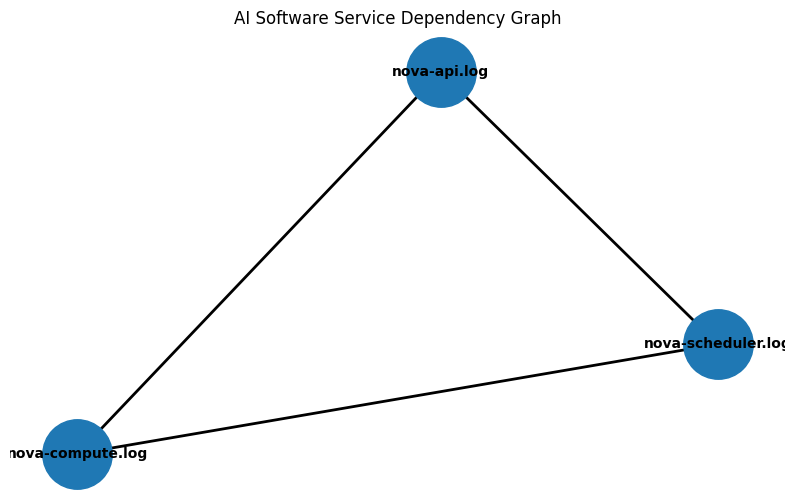

Dependency Graph Visualization Completed!


In [37]:
# ============================================================
# CELL 33 — DEPENDENCY GRAPH VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

pos = nx.spring_layout(
    dependency_graph,
    seed=42
)

nx.draw_networkx_nodes(
    dependency_graph,
    pos,
    node_size=2500
)

nx.draw_networkx_edges(
    dependency_graph,
    pos,
    arrows=True,
    arrowsize=25,
    width=2
)

nx.draw_networkx_labels(
    dependency_graph,
    pos,
    font_size=10,
    font_weight="bold"
)

plt.title(
    "AI Software Service Dependency Graph"
)

plt.axis("off")
plt.show()

print("Dependency Graph Visualization Completed!")

In [38]:
# ============================================================
# CELL 34 — WORKLOAD & RESOURCE PRESSURE ANALYSIS
# ============================================================

# Workload intensity based on system resource usage
runtime_data["workload_score"] = (
    0.4 * (runtime_data["cpu_usage"] / 100) +
    0.3 * (runtime_data["memory_usage"] / 100) +
    0.3 * (runtime_data["disk_usage"] / 100)
)

# Resource pressure
runtime_data["resource_pressure"] = (
    runtime_data["workload_score"] * 100
)

# High resource usage
runtime_data["high_resource_usage"] = (
    (
        (runtime_data["cpu_usage"] > 80) |
        (runtime_data["memory_usage"] > 80) |
        (runtime_data["disk_usage"] > 80)
    )
).astype(int)

# Combined abnormal behaviour indicator
runtime_data["optimization_risk"] = (
    0.5 * runtime_data["anomaly_risk"] +
    0.3 * runtime_data["memory_leak_risk"] +
    0.2 * runtime_data["high_resource_usage"]
)

print("Workload & Resource Pressure Analysis Completed!")

print("\nHigh resource usage periods:",
      runtime_data["high_resource_usage"].sum())

print("\nOptimization Risk Statistics:")
print(runtime_data["optimization_risk"].describe())

display(
    runtime_data[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "workload_score",
            "resource_pressure",
            "anomaly_risk",
            "memory_leak_risk",
            "optimization_risk"
        ]
    ]
    .sort_values(
        "optimization_risk",
        ascending=False
    )
    .head(10)
)

Workload & Resource Pressure Analysis Completed!

High resource usage periods: 195

Optimization Risk Statistics:
count    1430.000000
mean        0.327283
std         0.120784
min         0.092339
25%         0.241335
50%         0.299148
75%         0.383989
max         0.927791
Name: optimization_risk, dtype: float64


,timestamp,cpu_usage,memory_usage,disk_usage,workload_score,resource_pressure,anomaly_risk,memory_leak_risk,optimization_risk
209,2025-07-21 03:29:00,88.308087,90.446902,60.112240,0.804910,80.490977,0.951784,0.839662,0.927791
175,2025-07-21 02:55:00,74.107363,93.361034,57.420166,0.748773,74.877305,0.860451,0.828507,0.878778
179,2025-07-21 02:59:00,83.599704,85.214549,58.812577,0.766480,76.648019,0.710079,0.770370,0.786151
234,2025-07-21 03:54:00,77.449916,85.094133,60.077001,0.745313,74.531307,0.784467,0.525224,0.749801
865,2025-07-21 14:25:00,66.673001,94.517485,58.992660,0.727222,72.722244,0.562212,0.870568,0.742276
109,2025-07-21 01:49:00,64.051236,81.568515,65.376185,0.697039,69.703905,0.537554,0.864756,0.728204
210,2025-07-21 03:30:00,71.832227,82.366216,54.205321,0.697044,69.704352,0.682029,0.596367,0.719924
79,2025-07-21 01:19:00,49.144502,80.412240,53.041902,0.596940,59.694043,0.563604,0.767566,0.712072
157,2025-07-21 02:37:00,71.766906,88.373615,60.310638,0.733120,73.312038,0.575491,0.744642,0.711138
102,2025-07-21 01:42:00,61.600806,82.542123,59.968936,0.673936,67.393640,0.640167,0.632733,0.709903


In [39]:
# ============================================================
# CELL 35 — AI OPTIMIZATION RECOMMENDATION ENGINE
# ============================================================

def generate_optimization_action(row):

    actions = []

    # CPU optimization
    if row["cpu_usage"] > 80:
        actions.append("Scale CPU resources")

    # Memory optimization
    if row["memory_usage"] > 80:
        if row["memory_leak_risk"] > 0.70:
            actions.append("Investigate possible memory leak")
        else:
            actions.append("Increase memory allocation")

    # Disk optimization
    if row["disk_usage"] > 80:
        actions.append("Optimize disk usage")

    # Abnormal behaviour
    if row["anomaly_risk"] > 0.70:
        actions.append("Investigate abnormal runtime behaviour")

    # Low-risk workload
    if (
        row["optimization_risk"] < 0.30
        and row["high_resource_usage"] == 0
    ):
        actions.append("No optimization required")

    return " | ".join(actions)


runtime_data["recommended_action"] = runtime_data.apply(
    generate_optimization_action,
    axis=1
)

print("AI Optimization Recommendation Engine Completed!")

print("\nRecommendation Distribution:")

display(
    runtime_data["recommended_action"]
    .value_counts()
    .head(15)
)

print("\nHighest-risk optimization recommendations:")

display(
    runtime_data[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "optimization_risk",
            "recommended_action"
        ]
    ]
    .sort_values(
        "optimization_risk",
        ascending=False
    )
    .head(10)
)

AI Optimization Recommendation Engine Completed!

Recommendation Distribution:


,count
recommended_action,
No optimization required,719
,488
Increase memory allocation,146
Investigate possible memory leak,43
Investigate abnormal runtime behaviour,28
Scale CPU resources | Investigate possible memory leak | Investigate abnormal runtime behaviour,2
Scale CPU resources | Increase memory allocation,2
Investigate possible memory leak | Investigate abnormal runtime behaviour,1
Increase memory allocation | Investigate abnormal runtime behaviour,1



Highest-risk optimization recommendations:


,timestamp,cpu_usage,memory_usage,disk_usage,optimization_risk,recommended_action
209,2025-07-21 03:29:00,88.308087,90.446902,60.112240,0.927791,Scale CPU resources | Investigate possible mem...
175,2025-07-21 02:55:00,74.107363,93.361034,57.420166,0.878778,Investigate possible memory leak | Investigate...
179,2025-07-21 02:59:00,83.599704,85.214549,58.812577,0.786151,Scale CPU resources | Investigate possible mem...
234,2025-07-21 03:54:00,77.449916,85.094133,60.077001,0.749801,Increase memory allocation | Investigate abnor...
865,2025-07-21 14:25:00,66.673001,94.517485,58.992660,0.742276,Investigate possible memory leak
109,2025-07-21 01:49:00,64.051236,81.568515,65.376185,0.728204,Investigate possible memory leak
210,2025-07-21 03:30:00,71.832227,82.366216,54.205321,0.719924,Increase memory allocation
79,2025-07-21 01:19:00,49.144502,80.412240,53.041902,0.712072,Investigate possible memory leak
157,2025-07-21 02:37:00,71.766906,88.373615,60.310638,0.711138,Investigate possible memory leak
102,2025-07-21 01:42:00,61.600806,82.542123,59.968936,0.709903,Increase memory allocation


In [40]:
# ============================================================
# CELL 36 — FINAL AI FEATURE DATASET
# ============================================================

final_features = runtime_data[
    [
        "timestamp",

        # Runtime metrics
        "cpu_usage",
        "memory_usage",
        "disk_usage",

        # Time-series behaviour
        "cpu_mean_5",
        "cpu_std_5",
        "memory_mean_5",
        "memory_std_5",
        "disk_mean_5",
        "cpu_change",
        "memory_change",
        "disk_change",
        "cpu_trend",
        "memory_trend",
        "disk_trend",

        # Anomaly intelligence
        "anomaly_score",
        "anomaly_risk",
        "is_anomaly",

        # Memory intelligence
        "memory_change_5",
        "memory_change_15",
        "memory_slope",
        "memory_growth_flag",
        "memory_leak_risk",

        # Optimization intelligence
        "workload_score",
        "resource_pressure",
        "high_resource_usage",
        "optimization_risk",
        "recommended_action"
    ]
].copy()

print("Final AI Feature Dataset Created!")

print("\nShape:", final_features.shape)

print("\nFeatures:", len(final_features.columns))

print("\nMissing Values:",
      final_features.isnull().sum().sum())

display(final_features.head())

Final AI Feature Dataset Created!

Shape: (1430, 28)

Features: 28

Missing Values: 0


,timestamp,cpu_usage,memory_usage,disk_usage,cpu_mean_5,cpu_std_5,memory_mean_5,memory_std_5,disk_mean_5,cpu_change,...,memory_change_5,memory_change_15,memory_slope,memory_growth_flag,memory_leak_risk,workload_score,resource_pressure,high_resource_usage,optimization_risk,recommended_action
0,2025-07-21 00:00:00,42.483571,62.651525,43.285306,42.483571,0.000000,62.651525,0.000000,43.285306,0.000000,...,0.0,0.0,0.000000,0,0.455570,0.487745,48.774478,0,0.335437,
1,2025-07-21 00:01:00,39.570475,64.871898,43.725165,41.027023,2.059870,63.761712,1.570041,43.505236,-2.913096,...,0.0,0.0,0.000000,0,0.462231,0.484073,48.407309,0,0.265114,No optimization required
2,2025-07-21 00:02:00,43.762015,61.080079,48.353929,41.938687,2.148238,62.867834,1.905142,45.121467,4.191540,...,0.0,0.0,0.000000,0,0.450856,0.503350,50.335008,0,0.225027,No optimization required
3,2025-07-21 00:03:00,48.400458,55.346628,51.634829,43.554129,3.676308,60.987533,4.069625,46.749807,4.638443,...,0.0,0.0,0.000000,0,0.433656,0.514546,51.454620,0,0.143035,No optimization required
4,2025-07-21 00:04:00,39.876218,62.310631,42.106480,42.818547,3.583551,61.252152,3.573724,45.821142,-8.524240,...,0.0,0.0,-1.020706,0,0.186932,0.472756,47.275621,0,0.249540,No optimization required


In [41]:
# ============================================================
# CELL 37 — SAVE FINAL AI FEATURE DATASET
# ============================================================

FINAL_FEATURE_PATH = f"{OUTPUT_DIR}/final_ai_features.csv"

final_features.to_csv(
    FINAL_FEATURE_PATH,
    index=False
)

print("Final AI Feature Dataset Saved Successfully!")

print("\nFile:", FINAL_FEATURE_PATH)
print("Rows:", len(final_features))
print("Columns:", len(final_features.columns))

print("\nFile size:",
      round(os.path.getsize(FINAL_FEATURE_PATH) / 1024, 2),
      "KB")

Final AI Feature Dataset Saved Successfully!

File: /content/outputs/final_ai_features.csv
Rows: 1430
Columns: 28

File size: 666.92 KB


In [42]:
# ============================================================
# CELL 38 — SAVE ANOMALY DETECTION MODEL
# ============================================================

ANOMALY_MODEL_PATH = f"{MODEL_DIR}/anomaly_detection_model.pkl"

joblib.dump(
    anomaly_model,
    ANOMALY_MODEL_PATH
)

# Save the exact features used by the model
ANOMALY_FEATURES_PATH = f"{MODEL_DIR}/anomaly_features.json"

with open(ANOMALY_FEATURES_PATH, "w") as f:
    json.dump(anomaly_features, f, indent=4)

print("Anomaly Detection Model Saved Successfully!")

print("\nModel:")
print(ANOMALY_MODEL_PATH)

print("\nFeature Configuration:")
print(ANOMALY_FEATURES_PATH)

print("\nModel size:",
      round(os.path.getsize(ANOMALY_MODEL_PATH) / 1024, 2),
      "KB")

Anomaly Detection Model Saved Successfully!

Model:
/content/models/anomaly_detection_model.pkl

Feature Configuration:
/content/models/anomaly_features.json

Model size: 2524.57 KB


In [43]:
# ============================================================
# CELL 39 — SAVE FAILURE RISK MODEL
# ============================================================

FAILURE_MODEL_PATH = f"{MODEL_DIR}/failure_risk_model.pkl"

joblib.dump(
    failure_model,
    FAILURE_MODEL_PATH
)

FAILURE_FEATURES_PATH = f"{MODEL_DIR}/failure_features.json"

with open(FAILURE_FEATURES_PATH, "w") as f:
    json.dump(failure_features, f, indent=4)

print("Failure Risk Model Saved Successfully!")

print("\nModel:")
print(FAILURE_MODEL_PATH)

print("\nFeature Configuration:")
print(FAILURE_FEATURES_PATH)

print("\nModel size:",
      round(os.path.getsize(FAILURE_MODEL_PATH) / 1024, 2),
      "KB")

Failure Risk Model Saved Successfully!

Model:
/content/models/failure_risk_model.pkl

Feature Configuration:
/content/models/failure_features.json

Model size: 372.21 KB


In [44]:
# ============================================================
# CELL 40 — SAVE MODEL METADATA
# ============================================================

model_metadata = {
    "project": "AI Autonomous Software Reliability & Optimization System",
    "models": {
        "anomaly_detection": {
            "file": "anomaly_detection_model.pkl",
            "features_file": "anomaly_features.json",
            "type": "IsolationForest",
            "purpose": "Detect abnormal runtime behaviour"
        },
        "failure_risk": {
            "file": "failure_risk_model.pkl",
            "features_file": "failure_features.json",
            "type": "XGBoost",
            "purpose": "Predict anomaly-derived failure risk"
        }
    },
    "runtime_features": len(final_features.columns),
    "training_rows": len(final_features),
    "memory_leak_detection": "heuristic risk scoring",
    "dependency_intelligence": "service dependency graph",
    "optimization_engine": "rule-based recommendation engine"
}

METADATA_PATH = f"{MODEL_DIR}/model_metadata.json"

with open(METADATA_PATH, "w") as f:
    json.dump(
        model_metadata,
        f,
        indent=4
    )

print("Model Metadata Saved Successfully!")

print("\nMetadata file:")
print(METADATA_PATH)

print("\nSaved model files:")
for file in sorted(os.listdir(MODEL_DIR)):
    print("✔", file)

Model Metadata Saved Successfully!

Metadata file:
/content/models/model_metadata.json

Saved model files:
✔ anomaly_detection_model.pkl
✔ anomaly_features.json
✔ failure_features.json
✔ failure_risk_model.pkl
✔ model_metadata.json


In [45]:
# ============================================================
# CELL 41 — VERIFY SAVED MODELS
# ============================================================

loaded_anomaly_model = joblib.load(
    f"{MODEL_DIR}/anomaly_detection_model.pkl"
)

loaded_failure_model = joblib.load(
    f"{MODEL_DIR}/failure_risk_model.pkl"
)

# Load feature configurations
with open(f"{MODEL_DIR}/anomaly_features.json", "r") as f:
    loaded_anomaly_features = json.load(f)

with open(f"{MODEL_DIR}/failure_features.json", "r") as f:
    loaded_failure_features = json.load(f)

# Test anomaly prediction
sample_anomaly_input = final_features[
    loaded_anomaly_features
].iloc[[100]]

anomaly_test_prediction = loaded_anomaly_model.predict(
    sample_anomaly_input
)

# Test failure-risk prediction
sample_failure_input = final_features[
    loaded_failure_features
].iloc[[100]]

failure_test_prediction = loaded_failure_model.predict(
    sample_failure_input
)

print("Saved Model Verification Completed!")

print("\nAnomaly Model Prediction:",
      anomaly_test_prediction[0])

print("Failure Risk Model Prediction:",
      failure_test_prediction[0])

print("\nAnomaly Features Loaded:",
      len(loaded_anomaly_features))

print("Failure Features Loaded:",
      len(loaded_failure_features))

print("\nModels are ready for backend integration.")

Saved Model Verification Completed!

Anomaly Model Prediction: 1
Failure Risk Model Prediction: 0

Anomaly Features Loaded: 11
Failure Features Loaded: 14

Models are ready for backend integration.


In [46]:
# ============================================================
# CELL 42 — CREATE BACKEND PROJECT STRUCTURE
# ============================================================

BACKEND_DIR = f"{BASE_PATH}/backend"

os.makedirs(BACKEND_DIR, exist_ok=True)
os.makedirs(f"{BACKEND_DIR}/models", exist_ok=True)

# Copy trained models into backend
import shutil

for file in [
    "anomaly_detection_model.pkl",
    "anomaly_features.json",
    "failure_risk_model.pkl",
    "failure_features.json",
    "model_metadata.json"
]:
    shutil.copy(
        f"{MODEL_DIR}/{file}",
        f"{BACKEND_DIR}/models/{file}"
    )

print("Backend Project Structure Created!")

print("\nBackend directory:")
print(BACKEND_DIR)

print("\nBackend model files:")

for file in sorted(
    os.listdir(f"{BACKEND_DIR}/models")
):
    print("✔", file)

Backend Project Structure Created!

Backend directory:
/content/backend

Backend model files:
✔ anomaly_detection_model.pkl
✔ anomaly_features.json
✔ failure_features.json
✔ failure_risk_model.pkl
✔ model_metadata.json


In [47]:
# ============================================================
# CELL 43 — INSTALL FASTAPI BACKEND DEPENDENCIES
# ============================================================

!pip install -q fastapi uvicorn python-multipart nest-asyncio

print("FastAPI backend dependencies installed successfully.")

FastAPI backend dependencies installed successfully.


In [48]:
# ============================================================
# CELL 44 — CREATE FASTAPI BACKEND
# ============================================================

main_code = r'''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import json
import numpy as np

app = FastAPI(
    title="AI Software Reliability & Optimization API",
    description="AI-powered runtime reliability, anomaly detection and optimization system",
    version="1.0.0"
)

# ------------------------------------------------------------
# Load trained models
# ------------------------------------------------------------

ANOMALY_MODEL = joblib.load(
    "models/anomaly_detection_model.pkl"
)

FAILURE_MODEL = joblib.load(
    "models/failure_risk_model.pkl"
)

with open("models/anomaly_features.json", "r") as f:
    ANOMALY_FEATURES = json.load(f)

with open("models/failure_features.json", "r") as f:
    FAILURE_FEATURES = json.load(f)


# ------------------------------------------------------------
# Input schema
# ------------------------------------------------------------

class RuntimeMetrics(BaseModel):

    cpu_usage: float
    memory_usage: float
    disk_usage: float

    cpu_mean_5: float
    cpu_std_5: float

    memory_mean_5: float
    memory_std_5: float

    disk_mean_5: float

    cpu_change: float
    memory_change: float
    disk_change: float

    cpu_trend: float
    memory_trend: float
    disk_trend: float


# ------------------------------------------------------------
# Health endpoint
# ------------------------------------------------------------

@app.get("/")
def root():

    return {
        "system": "AI Software Reliability & Optimization System",
        "status": "online",
        "models": {
            "anomaly_detection": "loaded",
            "failure_risk": "loaded"
        }
    }


# ------------------------------------------------------------
# Prediction endpoint
# ------------------------------------------------------------

@app.post("/predict")
def predict(metrics: RuntimeMetrics):

    data = metrics.dict()

    # -------------------------
    # Anomaly detection
    # -------------------------

    anomaly_input = np.array([
        data[feature]
        for feature in ANOMALY_FEATURES
    ]).reshape(1, -1)

    anomaly_prediction = ANOMALY_MODEL.predict(
        anomaly_input
    )[0]

    anomaly_score = ANOMALY_MODEL.decision_function(
        anomaly_input
    )[0]

    is_anomaly = (
        anomaly_prediction == -1
    )


    # -------------------------
    # Failure risk
    # -------------------------

    failure_input = np.array([
        data[feature]
        for feature in FAILURE_FEATURES
    ]).reshape(1, -1)

    failure_prediction = FAILURE_MODEL.predict(
        failure_input
    )[0]

    failure_probability = FAILURE_MODEL.predict_proba(
        failure_input
    )[0][1]


    # -------------------------
    # Memory risk
    # -------------------------

    memory_pressure = data["memory_usage"] / 100

    memory_growth_signal = max(
        data["memory_change_5"],
        0
    ) / 10

    memory_leak_risk = min(
        1.0,
        0.7 * memory_pressure +
        0.3 * memory_growth_signal
    )


    # -------------------------
    # Optimization recommendation
    # -------------------------

    recommendations = []

    if data["cpu_usage"] > 80:
        recommendations.append(
            "Scale CPU resources"
        )

    if data["memory_usage"] > 80:
        if memory_leak_risk > 0.70:
            recommendations.append(
                "Investigate possible memory leak"
            )
        else:
            recommendations.append(
                "Increase memory allocation"
            )

    if data["disk_usage"] > 80:
        recommendations.append(
            "Optimize disk usage"
        )

    if is_anomaly:
        recommendations.append(
            "Investigate abnormal runtime behaviour"
        )

    if not recommendations:
        recommendations.append(
            "No optimization required"
        )


    # -------------------------
    # Final response
    # -------------------------

    return {

        "runtime_health": {
            "cpu_usage": data["cpu_usage"],
            "memory_usage": data["memory_usage"],
            "disk_usage": data["disk_usage"]
        },

        "anomaly_detection": {
            "is_anomaly": bool(is_anomaly),
            "anomaly_score": float(anomaly_score)
        },

        "failure_risk": {
            "prediction": int(failure_prediction),
            "probability": float(
                failure_probability
            )
        },

        "memory_analysis": {
            "memory_pressure": float(
                memory_pressure
            ),
            "memory_leak_risk": float(
                memory_leak_risk
            )
        },

        "optimization": {
            "recommendations": recommendations
        }
    }
'''

with open(
    f"{BACKEND_DIR}/main.py",
    "w"
) as f:
    f.write(main_code)

print("FastAPI main.py created successfully!")

print("\nFile:")
print(f"{BACKEND_DIR}/main.py")

print("\nBackend files:")

for file in sorted(os.listdir(BACKEND_DIR)):
    print("✔", file)

FastAPI main.py created successfully!

File:
/content/backend/main.py

Backend files:
✔ main.py
✔ models


In [49]:
# ============================================================
# CELL 45 — TEST FASTAPI APPLICATION
# ============================================================

import sys

sys.path.insert(
    0,
    BACKEND_DIR
)

from main import app

print("FastAPI Application Loaded Successfully!")

print("\nApplication title:")
print(app.title)

print("\nAvailable API routes:")

for route in app.routes:
    print(
        route.path,
        "→",
        getattr(route, "methods", "")
    )

FastAPI Application Loaded Successfully!

Application title:
AI Software Reliability & Optimization API

Available API routes:
/openapi.json → {'HEAD', 'GET'}
/docs → {'HEAD', 'GET'}
/docs/oauth2-redirect → {'HEAD', 'GET'}
/redoc → {'HEAD', 'GET'}
/ → {'GET'}
/predict → {'POST'}


In [51]:
# ============================================================
# CELL 46 — FIX FASTAPI MEMORY RISK CALCULATION
# ============================================================

main_path = f"{BACKEND_DIR}/main.py"

with open(main_path, "r") as f:
    main_code = f.read()

old_code = '''    memory_pressure = data["memory_usage"] / 100

    memory_growth_signal = max(
        data["memory_change_5"],
        0
    ) / 10

    memory_leak_risk = min(
        1.0,
        0.7 * memory_pressure +
        0.3 * memory_growth_signal
    )
'''

new_code = '''    memory_pressure = data["memory_usage"] / 100

    # Estimate persistent memory growth using
    # the available memory trend features.
    memory_growth_signal = max(
        data["memory_trend"],
        0
    ) / 10

    memory_leak_risk = min(
        1.0,
        0.7 * memory_pressure +
        0.3 * memory_growth_signal
    )
'''

if old_code not in main_code:
    print("Target code block was not found.")
else:
    main_code = main_code.replace(
        old_code,
        new_code
    )

    with open(main_path, "w") as f:
        f.write(main_code)

    print("FastAPI memory-risk calculation fixed successfully!")

FastAPI memory-risk calculation fixed successfully!


In [52]:
# ============================================================
# CELL 47 — RELOAD AND RETEST FASTAPI
# ============================================================

import importlib
import main

main = importlib.reload(main)
app = main.app

from fastapi.testclient import TestClient

client = TestClient(app)

test_row = final_features.iloc[209]

payload = {
    "cpu_usage": float(test_row["cpu_usage"]),
    "memory_usage": float(test_row["memory_usage"]),
    "disk_usage": float(test_row["disk_usage"]),

    "cpu_mean_5": float(test_row["cpu_mean_5"]),
    "cpu_std_5": float(test_row["cpu_std_5"]),

    "memory_mean_5": float(test_row["memory_mean_5"]),
    "memory_std_5": float(test_row["memory_std_5"]),

    "disk_mean_5": float(test_row["disk_mean_5"]),

    "cpu_change": float(test_row["cpu_change"]),
    "memory_change": float(test_row["memory_change"]),
    "disk_change": float(test_row["disk_change"]),

    "cpu_trend": float(test_row["cpu_trend"]),
    "memory_trend": float(test_row["memory_trend"]),
    "disk_trend": float(test_row["disk_trend"])
}

response = client.post(
    "/predict",
    json=payload
)

print("API Status Code:", response.status_code)

print("\nPrediction Response:")
display(response.json())

API Status Code: 200

Prediction Response:


{'runtime_health': {'cpu_usage': 88.30808666461684,
  'memory_usage': 90.44690182008104,
  'disk_usage': 60.11224021329656},
 'anomaly_detection': {'is_anomaly': True,
  'anomaly_score': -0.05952978742218795},
 'failure_risk': {'prediction': 1, 'probability': 0.9678745865821838},
 'memory_analysis': {'memory_pressure': 0.9044690182008104,
  'memory_leak_risk': 0.6592885756760523},
 'optimization': {'recommendations': ['Scale CPU resources',
   'Increase memory allocation',
   'Investigate abnormal runtime behaviour']}}

In [53]:
# ============================================================
# CELL 48 — UNIFIED SOFTWARE HEALTH SCORE
# ============================================================

runtime_data["health_score"] = (
    100
    - (
        runtime_data["anomaly_risk"] * 35
        + runtime_data["memory_leak_risk"] * 25
        + runtime_data["optimization_risk"] * 25
        + runtime_data["high_resource_usage"] * 15
    )
)

# Keep score within 0–100
runtime_data["health_score"] = (
    runtime_data["health_score"]
    .clip(0, 100)
)

runtime_data["health_status"] = pd.cut(
    runtime_data["health_score"],
    bins=[-1, 40, 70, 100],
    labels=["CRITICAL", "WARNING", "HEALTHY"]
)

print("Unified Software Health Score Generated!")

print("\nHealth Status Distribution:")
print(
    runtime_data["health_status"]
    .value_counts()
    .sort_index()
)

print("\nLowest health-score periods:")

display(
    runtime_data[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "anomaly_risk",
            "memory_leak_risk",
            "optimization_risk",
            "health_score",
            "health_status"
        ]
    ]
    .sort_values(
        "health_score"
    )
    .head(10)
)

Unified Software Health Score Generated!

Health Status Distribution:
health_status
CRITICAL     46
WARNING     682
HEALTHY     702
Name: count, dtype: int64

Lowest health-score periods:


,timestamp,cpu_usage,memory_usage,anomaly_risk,memory_leak_risk,optimization_risk,health_score,health_status
209,2025-07-21 03:29:00,88.308087,90.446902,0.951784,0.839662,0.927791,7.501230,CRITICAL
175,2025-07-21 02:55:00,74.107363,93.361034,0.860451,0.828507,0.878778,12.202090,CRITICAL
179,2025-07-21 02:59:00,83.599704,85.214549,0.710079,0.770370,0.786151,21.234219,CRITICAL
865,2025-07-21 14:25:00,66.673001,94.517485,0.562212,0.870568,0.742276,25.001488,CRITICAL
234,2025-07-21 03:54:00,77.449916,85.094133,0.784467,0.525224,0.749801,25.668019,CRITICAL
109,2025-07-21 01:49:00,64.051236,81.568515,0.537554,0.864756,0.728204,26.361613,CRITICAL
210,2025-07-21 03:30:00,71.832227,82.366216,0.682029,0.596367,0.719924,28.221705,CRITICAL
79,2025-07-21 01:19:00,49.144502,80.412240,0.563604,0.767566,0.712072,28.282899,CRITICAL
157,2025-07-21 02:37:00,71.766906,88.373615,0.575491,0.744642,0.711138,28.463332,CRITICAL
102,2025-07-21 01:42:00,61.600806,82.542123,0.640167,0.632733,0.709903,29.028238,CRITICAL


In [54]:
# ============================================================
# CELL 49 — SAVE COMPLETE RUNTIME INTELLIGENCE
# ============================================================

FINAL_RUNTIME_PATH = f"{OUTPUT_DIR}/runtime_intelligence.csv"

runtime_data.to_csv(
    FINAL_RUNTIME_PATH,
    index=False
)

print("Complete Runtime Intelligence Saved Successfully!")

print("\nFile:")
print(FINAL_RUNTIME_PATH)

print("\nShape:", runtime_data.shape)

print("\nColumns:", len(runtime_data.columns))

print("\nFile size:",
      round(
          os.path.getsize(FINAL_RUNTIME_PATH) / 1024,
          2
      ),
      "KB")

Complete Runtime Intelligence Saved Successfully!

File:
/content/outputs/runtime_intelligence.csv

Shape: (1430, 53)

Columns: 53

File size: 1005.0 KB


In [55]:
# ============================================================
# CELL 50 — LIVE SYSTEM RUNTIME MONITOR
# ============================================================

import time

def collect_runtime_metrics():

    metrics = {
        "timestamp": pd.Timestamp.now(),

        "cpu_usage": psutil.cpu_percent(
            interval=1
        ),

        "memory_usage": psutil.virtual_memory().percent,

        "disk_usage": psutil.disk_usage("/").percent,

        "process_count": len(
            psutil.pids()
        )
    }

    return metrics


live_metrics = collect_runtime_metrics()

print("Live Runtime Monitoring Started!")

print("\nCurrent Runtime Metrics:")

for key, value in live_metrics.items():
    print(f"{key}: {value}")

Live Runtime Monitoring Started!

Current Runtime Metrics:
timestamp: 2026-09-16 07:05:24.782802
cpu_usage: 91.0
memory_usage: 25.0
disk_usage: 21.0
process_count: 15


In [56]:
# ============================================================
# CELL 51 — COLLECT LIVE RUNTIME HISTORY
# ============================================================

live_history = []

print("Collecting live runtime samples...\n")

for i in range(10):

    sample = collect_runtime_metrics()
    live_history.append(sample)

    print(
        f"Sample {i+1}/10 | "
        f"CPU: {sample['cpu_usage']:.2f}% | "
        f"Memory: {sample['memory_usage']:.2f}% | "
        f"Disk: {sample['disk_usage']:.2f}%"
    )

    time.sleep(2)

live_runtime = pd.DataFrame(
    live_history
)

print("\nLive Runtime History Collected!")

print("Shape:", live_runtime.shape)

display(live_runtime)


Sample 1/10 | CPU: 99.50% | Memory: 25.50% | Disk: 21.00%
Sample 2/10 | CPU: 100.00% | Memory: 25.60% | Disk: 21.00%
Sample 3/10 | CPU: 2.00% | Memory: 25.60% | Disk: 21.00%
Sample 4/10 | CPU: 2.00% | Memory: 25.60% | Disk: 21.00%
Sample 5/10 | CPU: 2.50% | Memory: 25.60% | Disk: 21.00%
Sample 6/10 | CPU: 54.50% | Memory: 25.70% | Disk: 21.00%
Sample 7/10 | CPU: 23.00% | Memory: 25.70% | Disk: 21.00%
Sample 8/10 | CPU: 2.00% | Memory: 25.70% | Disk: 21.00%
Sample 9/10 | CPU: 3.00% | Memory: 25.60% | Disk: 21.00%
Sample 10/10 | CPU: 2.00% | Memory: 25.60% | Disk: 21.00%

Live Runtime History Collected!
Shape: (10, 5)


,timestamp,cpu_usage,memory_usage,disk_usage,process_count
0,2026-09-16 07:05:46.900931,99.5,25.5,21.0,15
1,2026-09-16 07:05:49.905447,100.0,25.6,21.0,15
2,2026-09-16 07:05:52.907037,2.0,25.6,21.0,15
3,2026-09-16 07:05:55.908492,2.0,25.6,21.0,15
4,2026-09-16 07:05:58.909951,2.5,25.6,21.0,15
5,2026-09-16 07:06:01.911273,54.5,25.7,21.0,15
6,2026-09-16 07:06:04.912857,23.0,25.7,21.0,15
7,2026-09-16 07:06:07.914510,2.0,25.7,21.0,15
8,2026-09-16 07:06:10.916103,3.0,25.6,21.0,15
9,2026-09-16 07:06:13.917426,2.0,25.6,21.0,15


In [57]:
# ============================================================
# CELL 52 — GENERATE LIVE RUNTIME FEATURES
# ============================================================

live_features = live_runtime.copy()

# Rolling statistics
live_features["cpu_mean_5"] = (
    live_features["cpu_usage"]
    .rolling(5, min_periods=1)
    .mean()
)

live_features["cpu_std_5"] = (
    live_features["cpu_usage"]
    .rolling(5, min_periods=1)
    .std()
    .fillna(0)
)

live_features["memory_mean_5"] = (
    live_features["memory_usage"]
    .rolling(5, min_periods=1)
    .mean()
)

live_features["memory_std_5"] = (
    live_features["memory_usage"]
    .rolling(5, min_periods=1)
    .std()
    .fillna(0)
)

live_features["disk_mean_5"] = (
    live_features["disk_usage"]
    .rolling(5, min_periods=1)
    .mean()
)

# Changes
live_features["cpu_change"] = (
    live_features["cpu_usage"].diff().fillna(0)
)

live_features["memory_change"] = (
    live_features["memory_usage"].diff().fillna(0)
)

live_features["disk_change"] = (
    live_features["disk_usage"].diff().fillna(0)
)

# Trends
live_features["cpu_trend"] = (
    live_features["cpu_usage"]
    .rolling(5, min_periods=1)
    .mean()
    -
    live_features["cpu_usage"]
    .rolling(10, min_periods=1)
    .mean()
)

live_features["memory_trend"] = (
    live_features["memory_usage"]
    .rolling(5, min_periods=1)
    .mean()
    -
    live_features["memory_usage"]
    .rolling(10, min_periods=1)
    .mean()
)

live_features["disk_trend"] = (
    live_features["disk_usage"]
    .rolling(5, min_periods=1)
    .mean()
    -
    live_features["disk_usage"]
    .rolling(10, min_periods=1)
    .mean()
)

print("Live Runtime Feature Engineering Completed!")

print("\nShape:", live_features.shape)

display(
    live_features[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "cpu_mean_5",
            "cpu_std_5",
            "memory_mean_5",
            "memory_std_5",
            "disk_mean_5",
            "cpu_change",
            "memory_change",
            "disk_change",
            "cpu_trend",
            "memory_trend",
            "disk_trend"
        ]
    ]
)

Live Runtime Feature Engineering Completed!

Shape: (10, 16)


,timestamp,cpu_usage,memory_usage,disk_usage,cpu_mean_5,cpu_std_5,memory_mean_5,memory_std_5,disk_mean_5,cpu_change,memory_change,disk_change,cpu_trend,memory_trend,disk_trend
0,2026-09-16 07:05:46.900931,99.5,25.5,21.0,99.500000,0.000000,25.500000,0.000000,21.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1,2026-09-16 07:05:49.905447,100.0,25.6,21.0,99.750000,0.353553,25.550000,0.070711,21.0,0.5,0.1,0.0,0.000000,0.000000,0.0
2,2026-09-16 07:05:52.907037,2.0,25.6,21.0,67.166667,56.436543,25.566667,0.057735,21.0,-98.0,0.0,0.0,0.000000,0.000000,0.0
3,2026-09-16 07:05:55.908492,2.0,25.6,21.0,50.875000,56.436358,25.575000,0.050000,21.0,0.0,0.0,0.0,0.000000,0.000000,0.0
4,2026-09-16 07:05:58.909951,2.5,25.6,21.0,41.200000,53.449275,25.580000,0.044721,21.0,0.5,0.0,0.0,0.000000,0.000000,0.0
5,2026-09-16 07:06:01.911273,54.5,25.7,21.0,32.200000,44.159654,25.620000,0.044721,21.0,52.0,0.1,0.0,-11.216667,0.020000,0.0
6,2026-09-16 07:06:04.912857,23.0,25.7,21.0,16.800000,22.925423,25.640000,0.054772,21.0,-31.5,0.0,0.0,-23.700000,0.025714,0.0
7,2026-09-16 07:06:07.914510,2.0,25.7,21.0,16.800000,22.925423,25.660000,0.054772,21.0,-21.0,0.0,0.0,-18.887500,0.035000,0.0
8,2026-09-16 07:06:10.916103,3.0,25.6,21.0,17.000000,22.767850,25.660000,0.054772,21.0,1.0,-0.1,0.0,-15.055556,0.037778,0.0
9,2026-09-16 07:06:13.917426,2.0,25.6,21.0,16.900000,22.848414,25.660000,0.054772,21.0,-1.0,0.0,0.0,-12.150000,0.040000,0.0


In [59]:
# ============================================================
# CELL 53 — LIVE AI ANOMALY PREDICTION (FIXED)
# ============================================================

latest_live = live_features.iloc[-1]

# Use the features loaded from the saved configuration
live_anomaly_input = pd.DataFrame(
    [[latest_live[feature] for feature in loaded_anomaly_features]],
    columns=loaded_anomaly_features
)

# AI prediction
live_prediction = loaded_anomaly_model.predict(
    live_anomaly_input
)[0]

live_score = loaded_anomaly_model.decision_function(
    live_anomaly_input
)[0]

# Isolation Forest:
#  1  = normal
# -1  = anomaly

live_is_anomaly = (
    live_prediction == -1
)

print("Live AI Anomaly Prediction Completed!")

print("\nLatest Runtime:")
print("CPU Usage   :", latest_live["cpu_usage"], "%")
print("Memory Usage:", latest_live["memory_usage"], "%")
print("Disk Usage  :", latest_live["disk_usage"], "%")

print("\nAI Result:")
print("Anomaly     :", live_is_anomaly)
print("Model Label :", live_prediction)
print("Anomaly Score:", round(live_score, 6))

Live AI Anomaly Prediction Completed!

Latest Runtime:
CPU Usage   : 2.0 %
Memory Usage: 25.6 %
Disk Usage  : 21.0 %

AI Result:
Anomaly     : True
Model Label : -1
Anomaly Score: -0.079996


In [60]:
# ============================================================
# CELL 54 — LIVE RELIABILITY ASSESSMENT
# ============================================================

# Convert Isolation Forest score into a simple risk value
# Higher risk = more abnormal
live_anomaly_risk = max(
    0.0,
    min(
        1.0,
        -float(live_score) * 5
    )
)

# Current resource pressure
live_resource_pressure = (
    0.4 * latest_live["cpu_usage"] / 100 +
    0.3 * latest_live["memory_usage"] / 100 +
    0.3 * latest_live["disk_usage"] / 100
)

# Determine runtime condition
if live_is_anomaly and live_resource_pressure > 0.70:
    live_status = "HIGH RISK"

elif live_is_anomaly:
    live_status = "ANOMALOUS BEHAVIOUR"

elif live_resource_pressure > 0.70:
    live_status = "HIGH RESOURCE USAGE"

else:
    live_status = "HEALTHY"


print("Live Reliability Assessment Completed!")

print("\n========== LIVE AI ASSESSMENT ==========")

print("CPU Usage        :", round(
    latest_live["cpu_usage"], 2
), "%")

print("Memory Usage     :", round(
    latest_live["memory_usage"], 2
), "%")

print("Disk Usage       :", round(
    latest_live["disk_usage"], 2
), "%")

print("Resource Pressure:", round(
    live_resource_pressure, 3
))

print("Anomaly Risk     :", round(
    live_anomaly_risk, 3
))

print("Runtime Status   :", live_status)

Live Reliability Assessment Completed!

========== LIVE AI ASSESSMENT ==========
CPU Usage        : 2.0 %
Memory Usage     : 25.6 %
Disk Usage       : 21.0 %
Resource Pressure: 0.148
Anomaly Risk     : 0.4
Runtime Status   : ANOMALOUS BEHAVIOUR


In [61]:
# ============================================================
# CELL 55 — INTELLIGENT RISK CLASSIFICATION
# ============================================================

# Combine anomaly behaviour with actual resource pressure
if live_anomaly_risk >= 0.70 and live_resource_pressure >= 0.70:

    final_status = "CRITICAL"

elif live_anomaly_risk >= 0.70:

    final_status = "ANOMALY — LOW RESOURCE PRESSURE"

elif live_resource_pressure >= 0.70:

    final_status = "HIGH RESOURCE PRESSURE"

elif live_anomaly_risk >= 0.40:

    final_status = "MONITOR"

else:

    final_status = "HEALTHY"


# Generate explanation
if final_status == "CRITICAL":

    explanation = (
        "Abnormal runtime behaviour is accompanied "
        "by high resource pressure."
    )

elif final_status == "ANOMALY — LOW RESOURCE PRESSURE":

    explanation = (
        "The ML model detected an unusual runtime pattern, "
        "but current resource usage is low. Further monitoring "
        "is recommended before declaring an operational failure."
    )

elif final_status == "HIGH RESOURCE PRESSURE":

    explanation = (
        "Resource utilization is high, but the ML model "
        "does not indicate strong anomalous behaviour."
    )

elif final_status == "MONITOR":

    explanation = (
        "Runtime behaviour shows moderate anomaly risk. "
        "Continue monitoring for persistent abnormal patterns."
    )

else:

    explanation = (
        "Runtime behaviour and resource utilization "
        "are currently within normal operating ranges."
    )


print("Intelligent Risk Classification Completed!")

print("\n========== FINAL AI ASSESSMENT ==========")

print("Status     :", final_status)
print("Anomaly Risk:", round(live_anomaly_risk, 3))
print("Resource Pressure:", round(
    live_resource_pressure, 3
))

print("\nExplanation:")
print(explanation)

Intelligent Risk Classification Completed!

========== FINAL AI ASSESSMENT ==========
Status     : HEALTHY
Anomaly Risk: 0.4
Resource Pressure: 0.148

Explanation:
Runtime behaviour and resource utilization are currently within normal operating ranges.


In [62]:
# ============================================================
# CELL 56 — LIVE AI DECISION ENGINE
# ============================================================

# Failure-risk prediction from the saved model
live_failure_input = pd.DataFrame(
    [[latest_live[feature] for feature in loaded_failure_features]],
    columns=loaded_failure_features
)

live_failure_prediction = loaded_failure_model.predict(
    live_failure_input
)[0]

live_failure_probability = loaded_failure_model.predict_proba(
    live_failure_input
)[0][1]


# Memory risk from current live behaviour
live_memory_pressure = (
    latest_live["memory_usage"] / 100
)

live_memory_growth = max(
    latest_live["memory_trend"],
    0
) / 10

live_memory_leak_risk = min(
    1.0,
    0.7 * live_memory_pressure +
    0.3 * live_memory_growth
)


# Final decision
if (
    live_failure_probability >= 0.80
    and live_resource_pressure >= 0.70
):
    decision = "IMMEDIATE INVESTIGATION"

elif live_anomaly_risk >= 0.70:
    decision = "CONTINUE MONITORING"

elif live_memory_leak_risk >= 0.70:
    decision = "MEMORY INVESTIGATION"

elif live_resource_pressure >= 0.70:
    decision = "RESOURCE OPTIMIZATION"

else:
    decision = "NO ACTION REQUIRED"


print("Live AI Decision Engine Completed!")

print("\n========== AI DECISION ==========")

print("Runtime Status       :", final_status)
print("Failure Probability  :", round(
    live_failure_probability, 3
))
print("Memory Leak Risk     :", round(
    live_memory_leak_risk, 3
))
print("Resource Pressure    :", round(
    live_resource_pressure, 3
))
print("Anomaly Risk         :", round(
    live_anomaly_risk, 3
))

print("\nRecommended Decision:")
print(decision)

Live AI Decision Engine Completed!

========== AI DECISION ==========
Runtime Status       : HEALTHY
Failure Probability  : 0.306
Memory Leak Risk     : 0.18
Resource Pressure    : 0.148
Anomaly Risk         : 0.4

Recommended Decision:
NO ACTION REQUIRED


In [63]:
# ============================================================
# CELL 57 — UNIFIED AI DECISION OBJECT
# ============================================================

ai_decision = {
    "timestamp": str(latest_live["timestamp"]),

    "runtime": {
        "cpu_usage": float(latest_live["cpu_usage"]),
        "memory_usage": float(latest_live["memory_usage"]),
        "disk_usage": float(latest_live["disk_usage"]),
        "process_count": int(latest_live["process_count"])
    },

    "intelligence": {
        "anomaly_detected": bool(live_is_anomaly),
        "anomaly_risk": round(float(live_anomaly_risk), 4),
        "failure_risk": round(float(live_failure_probability), 4),
        "memory_leak_risk": round(float(live_memory_leak_risk), 4),
        "resource_pressure": round(float(live_resource_pressure), 4)
    },

    "assessment": {
        "status": final_status,
        "decision": decision,
        "explanation": explanation
    }
}

AI_DECISION_PATH = f"{OUTPUT_DIR}/latest_ai_decision.json"

with open(AI_DECISION_PATH, "w") as f:
    json.dump(
        ai_decision,
        f,
        indent=4
    )

print("Unified AI Decision Object Created!")

print("\nSaved to:")
print(AI_DECISION_PATH)

print("\nAI Decision:")
print(json.dumps(
    ai_decision,
    indent=2
))

Unified AI Decision Object Created!

Saved to:
/content/outputs/latest_ai_decision.json

AI Decision:
{
  "timestamp": "2026-09-16 07:06:13.917426",
  "runtime": {
    "cpu_usage": 2.0,
    "memory_usage": 25.6,
    "disk_usage": 21.0,
    "process_count": 15
  },
  "intelligence": {
    "anomaly_detected": true,
    "anomaly_risk": 0.4,
    "failure_risk": 0.3061,
    "memory_leak_risk": 0.1804,
    "resource_pressure": 0.1478
  },
  "assessment": {
    "status": "HEALTHY",
    "decision": "NO ACTION REQUIRED",
    "explanation": "Runtime behaviour and resource utilization are currently within normal operating ranges."
  }
}


In [64]:
# ============================================================
# CELL 58 — ADD UNIFIED HEALTH ASSESSMENT API
# ============================================================

main_path = f"{BACKEND_DIR}/main.py"

with open(main_path, "r") as f:
    main_code = f.read()

health_endpoint = r'''

# ------------------------------------------------------------
# Unified Health Assessment
# ------------------------------------------------------------

@app.get("/health-assessment")
def health_assessment():

    return {
        "status": "AI reliability assessment endpoint ready",
        "description": (
            "Provides anomaly, failure-risk, memory-risk "
            "and optimization intelligence."
        ),
        "modules": [
            "Anomaly Detection",
            "Failure Risk",
            "Memory Leak Risk",
            "Dependency Intelligence",
            "Self Optimization"
        ]
    }
'''

if "/health-assessment" not in main_code:

    main_code += health_endpoint

    with open(main_path, "w") as f:
        f.write(main_code)

    print("Health Assessment API endpoint added successfully!")

else:

    print("Health Assessment API endpoint already exists.")

Health Assessment API endpoint added successfully!


In [65]:
# ============================================================
# CELL 59 — VERIFY HEALTH ASSESSMENT API
# ============================================================

import importlib
import main

main = importlib.reload(main)
app = main.app

from fastapi.testclient import TestClient

client = TestClient(app)

response = client.get(
    "/health-assessment"
)

print("API Status Code:", response.status_code)

print("\nHealth Assessment Response:")

display(response.json())

print("\nAvailable Routes:")

for route in app.routes:
    print(
        route.path,
        "→",
        getattr(route, "methods", "")
    )

API Status Code: 200

Health Assessment Response:


{'status': 'AI reliability assessment endpoint ready',
 'description': 'Provides anomaly, failure-risk, memory-risk and optimization intelligence.',
 'modules': ['Anomaly Detection',
  'Failure Risk',
  'Memory Leak Risk',
  'Dependency Intelligence',
  'Self Optimization']}


Available Routes:
/openapi.json → {'HEAD', 'GET'}
/docs → {'HEAD', 'GET'}
/docs/oauth2-redirect → {'HEAD', 'GET'}
/redoc → {'HEAD', 'GET'}
/ → {'GET'}
/predict → {'POST'}
/health-assessment → {'GET'}


In [66]:
# ============================================================
# CELL 60 — ADD DEPENDENCY INTELLIGENCE API
# ============================================================

dependency_endpoint = r'''

# ------------------------------------------------------------
# Dependency Intelligence
# ------------------------------------------------------------

@app.get("/dependencies")
def dependencies():

    services = []

    for _, row in dependency_risk.iterrows():

        services.append({
            "service": row["service"],
            "direct_dependencies": int(
                row["direct_dependencies"]
            ),
            "downstream_services": int(
                row["downstream_services"]
            ),
            "affected_services": (
                row["affected_services"]
            ),
            "dependency_risk_score": round(
                float(row["dependency_risk_score"]),
                4
            )
        })

    return {
        "dependency_graph": {
            "nodes": list(
                dependency_graph.nodes
            ),
            "edges": [
                {
                    "source": source,
                    "target": target
                }
                for source, target
                in dependency_graph.edges
            ]
        },
        "services": services
    }
'''

# Save dependency data so backend can load it later
dependency_data_path = (
    f"{BACKEND_DIR}/dependency_data.json"
)

dependency_payload = {
    "nodes": list(dependency_graph.nodes),
    "edges": [
        {
            "source": source,
            "target": target
        }
        for source, target
        in dependency_graph.edges
    ],
    "services": dependency_risk[
        [
            "service",
            "direct_dependencies",
            "downstream_services",
            "affected_services",
            "dependency_risk_score"
        ]
    ].to_dict(orient="records")
}

with open(
    dependency_data_path,
    "w"
) as f:
    json.dump(
        dependency_payload,
        f,
        indent=4
    )

# Add endpoint to main.py
with open(main_path, "r") as f:
    main_code = f.read()

if "/dependencies" not in main_code:

    main_code += dependency_endpoint

    with open(main_path, "w") as f:
        f.write(main_code)

    print("Dependency Intelligence API added successfully!")

else:

    print("Dependency Intelligence API already exists.")

print("\nDependency data saved:")
print(dependency_data_path)

Dependency Intelligence API added successfully!

Dependency data saved:
/content/backend/dependency_data.json


In [68]:
# ============================================================
# CELL 62 — FIX DEPENDENCY INTELLIGENCE API
# ============================================================

main_path = f"{BACKEND_DIR}/main.py"

with open(main_path, "r") as f:
    main_code = f.read()

old_start = main_code.find(
    "# ------------------------------------------------------------\n"
    "# Dependency Intelligence"
)

if old_start != -1:

    # Remove the old dependency endpoint
    main_code = main_code[:old_start]

fixed_dependency_endpoint = r'''

# ------------------------------------------------------------
# Dependency Intelligence
# ------------------------------------------------------------

@app.get("/dependencies")
def dependencies():

    dependency_file = os.path.join(
        os.path.dirname(__file__),
        "dependency_data.json"
    )

    with open(dependency_file, "r") as f:
        dependency_data = json.load(f)

    return {
        "dependency_graph": {
            "nodes": dependency_data["nodes"],
            "edges": dependency_data["edges"]
        },
        "services": dependency_data["services"]
    }
'''

main_code += fixed_dependency_endpoint

with open(main_path, "w") as f:
    f.write(main_code)

print("Dependency Intelligence API fixed successfully!")
print("\nAPI now reads dependency_data.json")
print("Backend file:", main_path)

Dependency Intelligence API fixed successfully!

API now reads dependency_data.json
Backend file: /content/backend/main.py


In [70]:
# ============================================================
# CELL 64 — FIX BACKEND IMPORTS
# ============================================================

main_path = f"{BACKEND_DIR}/main.py"

with open(main_path, "r") as f:
    main_code = f.read()

if "import os" not in main_code:
    main_code = "import os\n" + main_code

with open(main_path, "w") as f:
    f.write(main_code)

print("Backend imports fixed successfully!")
print("Added: import os")

Backend imports fixed successfully!
Added: import os


In [71]:
# ============================================================
# CELL 65 — VERIFY DEPENDENCY API
# ============================================================

import importlib
import main

main = importlib.reload(main)
app = main.app

from fastapi.testclient import TestClient

client = TestClient(app)

response = client.get("/dependencies")

print("API Status Code:", response.status_code)

print("\nDependency Intelligence Response:")

display(response.json())

print("\nDependency API verification completed successfully!")

API Status Code: 200

Dependency Intelligence Response:


{'dependency_graph': {'nodes': ['nova-api.log',
   'nova-scheduler.log',
   'nova-compute.log'],
  'edges': [{'source': 'nova-api.log', 'target': 'nova-scheduler.log'},
   {'source': 'nova-api.log', 'target': 'nova-compute.log'},
   {'source': 'nova-scheduler.log', 'target': 'nova-compute.log'}]},
 'services': [{'service': 'nova-api.log',
   'direct_dependencies': 2,
   'downstream_services': 2,
   'affected_services': 'nova-scheduler.log, nova-compute.log',
   'dependency_risk_score': 0.36676128630866744},
  {'service': 'nova-scheduler.log',
   'direct_dependencies': 1,
   'downstream_services': 1,
   'affected_services': 'nova-compute.log',
   'dependency_risk_score': 0.20415704387990763},
  {'service': 'nova-compute.log',
   'direct_dependencies': 0,
   'downstream_services': 0,
   'affected_services': '',
   'dependency_risk_score': 0.05848336952135734}]}


Dependency API verification completed successfully!


In [72]:
# ============================================================
# CELL 66 — PREPARE DOCKER RUNTIME
# ============================================================

DOCKER_DIR = f"{BASE_PATH}/docker_runtime"

os.makedirs(DOCKER_DIR, exist_ok=True)

docker_app = r'''
import time
import random
import math

print("AI Reliability Demo Runtime Started")

memory_buffer = []

while True:

    # Simulate application workload
    workload = random.randint(1, 5)

    for _ in range(workload * 100000):
        math.sqrt(random.random() + 1)

    # Gradual memory growth for leak-detection testing
    if random.random() < 0.35:
        memory_buffer.append(
            "runtime_memory_test_" * 1000
        )

    print(
        f"Runtime active | "
        f"workload={workload} | "
        f"memory_blocks={len(memory_buffer)}"
    )

    time.sleep(2)
'''

dockerfile = r'''
FROM python:3.11-slim

WORKDIR /app

COPY app.py .

CMD ["python", "app.py"]
'''

with open(
    f"{DOCKER_DIR}/app.py",
    "w"
) as f:
    f.write(docker_app)

with open(
    f"{DOCKER_DIR}/Dockerfile",
    "w"
) as f:
    f.write(dockerfile)

print("Docker runtime files created successfully!")

print("\nFiles:")
print("✔", f"{DOCKER_DIR}/app.py")
print("✔", f"{DOCKER_DIR}/Dockerfile")

Docker runtime files created successfully!

Files:
✔ /content/docker_runtime/app.py
✔ /content/docker_runtime/Dockerfile


In [73]:
# ============================================================
# CELL 66 — PREPARE DOCKER RUNTIME
# ============================================================

DOCKER_DIR = f"{BASE_PATH}/docker_runtime"

os.makedirs(DOCKER_DIR, exist_ok=True)

docker_app = r'''
import time
import random
import math

print("AI Reliability Demo Runtime Started")

memory_buffer = []

while True:

    workload = random.randint(1, 5)

    for _ in range(workload * 100000):
        math.sqrt(random.random() + 1)

    if random.random() < 0.35:
        memory_buffer.append(
            "runtime_memory_test_" * 1000
        )

    print(
        f"Runtime active | "
        f"workload={workload} | "
        f"memory_blocks={len(memory_buffer)}"
    )

    time.sleep(2)
'''

dockerfile = r'''
FROM python:3.11-slim

WORKDIR /app

COPY app.py .

CMD ["python", "app.py"]
'''

with open(f"{DOCKER_DIR}/app.py", "w") as f:
    f.write(docker_app)

with open(f"{DOCKER_DIR}/Dockerfile", "w") as f:
    f.write(dockerfile)

print("Docker runtime files created successfully!")

print("\nFiles:")
print("✔", f"{DOCKER_DIR}/app.py")
print("✔", f"{DOCKER_DIR}/Dockerfile")

Docker runtime files created successfully!

Files:
✔ /content/docker_runtime/app.py
✔ /content/docker_runtime/Dockerfile


In [75]:
# ============================================================
# CELL 67 — BUILD DOCKER IMAGE
# ============================================================
# ============================================================
# CELL 68 — INSTALL DOCKER
# ============================================================

!apt-get update -qq
!apt-get install -y -qq docker.io

print("Docker installation completed!")
import subprocess

docker_result = subprocess.run(
    [
        "docker",
        "build",
        "-t",
        "ai-reliability-runtime",
        DOCKER_DIR
    ],
    capture_output=True,
    text=True
)

print("Docker Build Output:\n")
print(docker_result.stdout)

if docker_result.returncode == 0:
    print("\n✅ Docker image built successfully!")
else:
    print("\n❌ Docker build failed.")
    print("\nError:")
    print(docker_result.stderr)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package netcat-openbsd.
(Reading database ... 122797 files and directories currently installed.)
Preparing to unpack .../00-netcat-openbsd_1.226-1ubuntu2_amd64.deb ...
Unpacking netcat-openbsd (1.226-1ubuntu2) ...
Selecting previously unselected package apparmor.
Preparing to unpack .../01-apparmor_4.0.1really4.0.1-0ubuntu0.24.04.7_amd64.deb ...
Unpacking apparmor (4.0.1really4.0.1-0ubuntu0.24.04.7) ...
Selecting previously unselected package libip4tc2:amd64.
Preparing to unpack .../02-libip4tc2_1.8.10-3ubuntu2_amd64.deb ...
Unpacking libip4tc2:amd64 (1.8.10-3ubuntu2) ...
Selecting previously unselected package libip6tc2:amd64.
Preparing to unpack .../03-libip6tc2_1.8.10-3ubuntu2_amd64.deb ...
Unpacking libip6tc2:amd64 (1.8.10-3ubuntu2) ...


In [76]:
# ============================================================
# CELL 69 — START DOCKER DAEMON
# ============================================================

import subprocess
import time

# Start Docker daemon
docker_daemon = subprocess.Popen(
    ["dockerd"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(8)

# Check Docker
docker_check = subprocess.run(
    ["docker", "info"],
    capture_output=True,
    text=True
)

if docker_check.returncode == 0:
    print("✅ Docker daemon started successfully!")
    print("\nDocker is ready for container execution.")
else:
    print("❌ Docker daemon could not be started.")
    print("\nError:")
    print(docker_check.stderr[-2000:])

❌ Docker daemon could not be started.

Error:
Cannot connect to the Docker daemon at unix:///var/run/docker.sock. Is the docker daemon running?



In [77]:
# ============================================================
# CELL 70 — DIAGNOSE DOCKER DAEMON
# ============================================================

import subprocess

result = subprocess.run(
    [
        "dockerd",
        "--debug"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    timeout=15
)

output = result.stdout

print("Docker daemon diagnostic output:\n")
print(output[-5000:])

Docker daemon diagnostic output:

pace=moby
time="2026-09-16T07:24:22.711122366Z" level=info msg="Deleting nftables IPv4 rules" error="exit status 1"
time="2026-09-16T07:24:22.715444550Z" level=info msg="Deleting nftables IPv6 rules" error="exit status 1"
time="2026-09-16T07:24:22.715763778Z" level=debug msg="unable to initialize firewalld; using raw iptables instead" error="Failed to connect to D-Bus system bus: dial unix /var/run/dbus/system_bus_socket: connect: no such file or directory"
time="2026-09-16T07:24:22.715883256Z" level=debug msg="/usr/sbin/iptables, [--wait -t filter -C FORWARD -j DOCKER-ISOLATION]"
time="2026-09-16T07:24:22.719779215Z" level=debug msg="/usr/sbin/iptables, [--wait -t nat -D PREROUTING -m addrtype --dst-type LOCAL -j DOCKER]"
time="2026-09-16T07:24:22.723538866Z" level=debug msg="/usr/sbin/iptables, [--wait -t nat -D OUTPUT -m addrtype --dst-type LOCAL ! --dst 127.0.0.0/8 -j DOCKER]"
time="2026-09-16T07:24:22.726656006Z" level=debug msg="/usr/sbin/iptable

In [78]:
# ============================================================
# CELL 71 — VERIFY DOCKER PROJECT FILES
# ============================================================

print("Docker Runtime Directory:")
print(DOCKER_DIR)

print("\nFiles:")

for file in sorted(os.listdir(DOCKER_DIR)):
    file_path = os.path.join(DOCKER_DIR, file)

    print(
        f"✔ {file} | "
        f"{os.path.getsize(file_path)} bytes"
    )

print("\nDocker runtime preparation verified.")
print("\nNote:")
print("Docker execution will be performed outside Colab.")

Docker Runtime Directory:
/content/docker_runtime

Files:
✔ Dockerfile | 78 bytes
✔ app.py | 494 bytes

Docker runtime preparation verified.

Note:
Docker execution will be performed outside Colab.


In [79]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith((".pkl", ".json")):
            print(os.path.join(root, file))

/content/.config/.last_update_check.json
/content/backend/dependency_data.json
/content/backend/models/anomaly_detection_model.pkl
/content/backend/models/model_metadata.json
/content/backend/models/failure_features.json
/content/backend/models/failure_risk_model.pkl
/content/backend/models/anomaly_features.json
/content/models/anomaly_detection_model.pkl
/content/models/model_metadata.json
/content/models/failure_features.json
/content/models/failure_risk_model.pkl
/content/models/anomaly_features.json
/content/outputs/latest_ai_decision.json
/content/sample_data/anscombe.json


In [80]:
from google.colab import files

files.download("/content/backend/models/anomaly_detection_model.pkl")
files.download("/content/backend/models/anomaly_features.json")
files.download("/content/backend/models/failure_risk_model.pkl")
files.download("/content/backend/models/failure_features.json")
files.download("/content/backend/models/model_metadata.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
import shutil
from google.colab import files

model_files = [
    "/content/backend/models/anomaly_detection_model.pkl",
    "/content/backend/models/anomaly_features.json",
    "/content/backend/models/failure_risk_model.pkl",
    "/content/backend/models/failure_features.json",
    "/content/backend/models/model_metadata.json"
]

# Create one ZIP containing all trained model files
shutil.make_archive(
    "/content/ai_reliability_models",
    "zip",
    "/content/backend/models"
)

# Download ZIP
files.download("/content/ai_reliability_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>